# Goal

## To Predict customer churn in e-commerce
Why it matters-
Reduce customer loss;
Improve retention strategy

# Data Understanding

In [100]:
import sys
!{sys.executable} -m pip install numpy==1.23.5 pandas scikit-learn matplotlib seaborn shap

In [102]:
import sys
print(sys.executable)

import numpy as np
print(np.__version__)

C:\Users\ASUS\anaconda3\envs\churn_env\python.exe
1.23.5


In [104]:
#Load Dataset-Bring data into the analysis environment
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_theme(color_codes=True)

In [106]:
df = pd.read_excel('E_comm.xlsx')

In [107]:
#Data Overview-Understand structure, types, scale
df.head(n=8)

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Mobile,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Mobile,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Mobile,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Mobile,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60
5,50006,1,0.0,Computer,1,22.0,Debit Card,Female,3.0,5,Mobile,5,Single,2,1,22.0,4.0,6.0,7.0,139.19
6,50007,1,NaN,Mobile,3,11.0,Cash on Delivery,Male,2.0,3,Laptop & Accessory,2,Divorced,4,0,14.0,0.0,1.0,0.0,120.86
7,50008,1,NaN,Mobile,1,6.0,CC,Male,3.0,3,Mobile,2,Divorced,3,1,16.0,2.0,2.0,0.0,122.93


<Axes: xlabel='Churn', ylabel='count'>

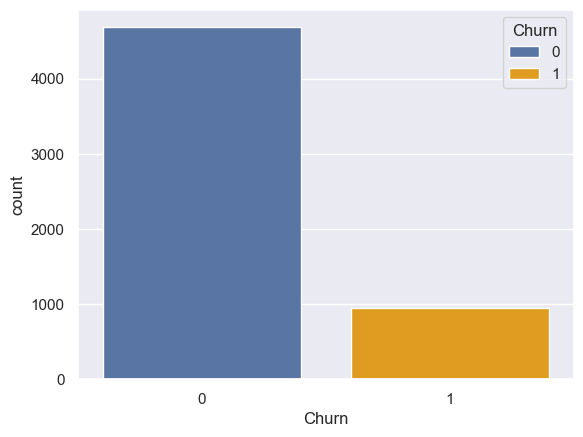

In [110]:
#Target Variable Analysis- Checking class imbalance for Churn vs no Churn
palette = ["#4C72B0", "orange"]
sns.countplot(x='Churn',hue='Churn', data=df, palette=palette)

In [112]:
df.dtypes

CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice            object
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode            object
Gender                          object
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                object
SatisfactionScore                int64
MaritalStatus                   object
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                 float64
dtype: object

In [114]:
df.shape[1]

20

In [116]:
#Check the number of unique values from all of the objects datatype
df.select_dtypes(include='object').nunique()

PreferredLoginDevice    2
PreferredPaymentMode    7
Gender                  2
PreferedOrderCat        5
MaritalStatus           3
dtype: int64

In [118]:
#Remove CustomerID Column
df.drop(columns='CustomerID', inplace=True)
df.head()

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,1,4.0,Mobile,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,1,NaN,Mobile,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,1,NaN,Mobile,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,1,0.0,Mobile,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,1,0.0,Mobile,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


# Exploratory Data Analysis 

In [121]:
cat_df = df.select_dtypes(include = 'object')

In [123]:
print(cat_df.columns)

Index(['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
       'PreferedOrderCat', 'MaritalStatus'],
      dtype='object')


<Axes: xlabel='Churn', ylabel='DaySinceLastOrder'>

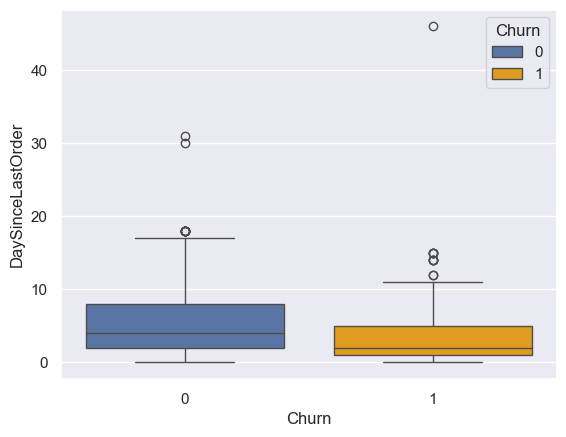

In [125]:
palette = ["#4C72B0", "orange"]
sns.boxplot(x='Churn',hue='Churn', y='DaySinceLastOrder', data=df,palette=palette)

Median (the middle line in the box)
Non-churned customers (0): ~4 days since last purchase
Churned customers (1): ~2 days since last purchase
So customers who churned generally waited for a shorter time before their last purchase.
This goes AGAINST the fundamental e-commerce Churn rule:
The longer a customer stays inactive, the higher the probability they Churn. So we need to check other features.

<Axes: xlabel='Churn', ylabel='CashbackAmount'>

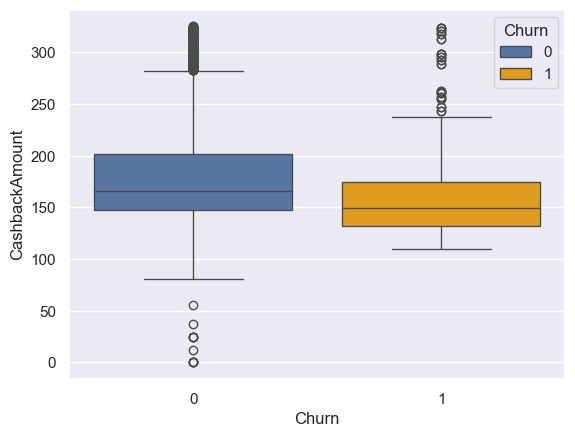

In [128]:
palette = ["#4C72B0", "orange"]
sns.boxplot(x='Churn',hue='Churn', y='CashbackAmount', data=df,palette=palette)

## Univariate Analysis

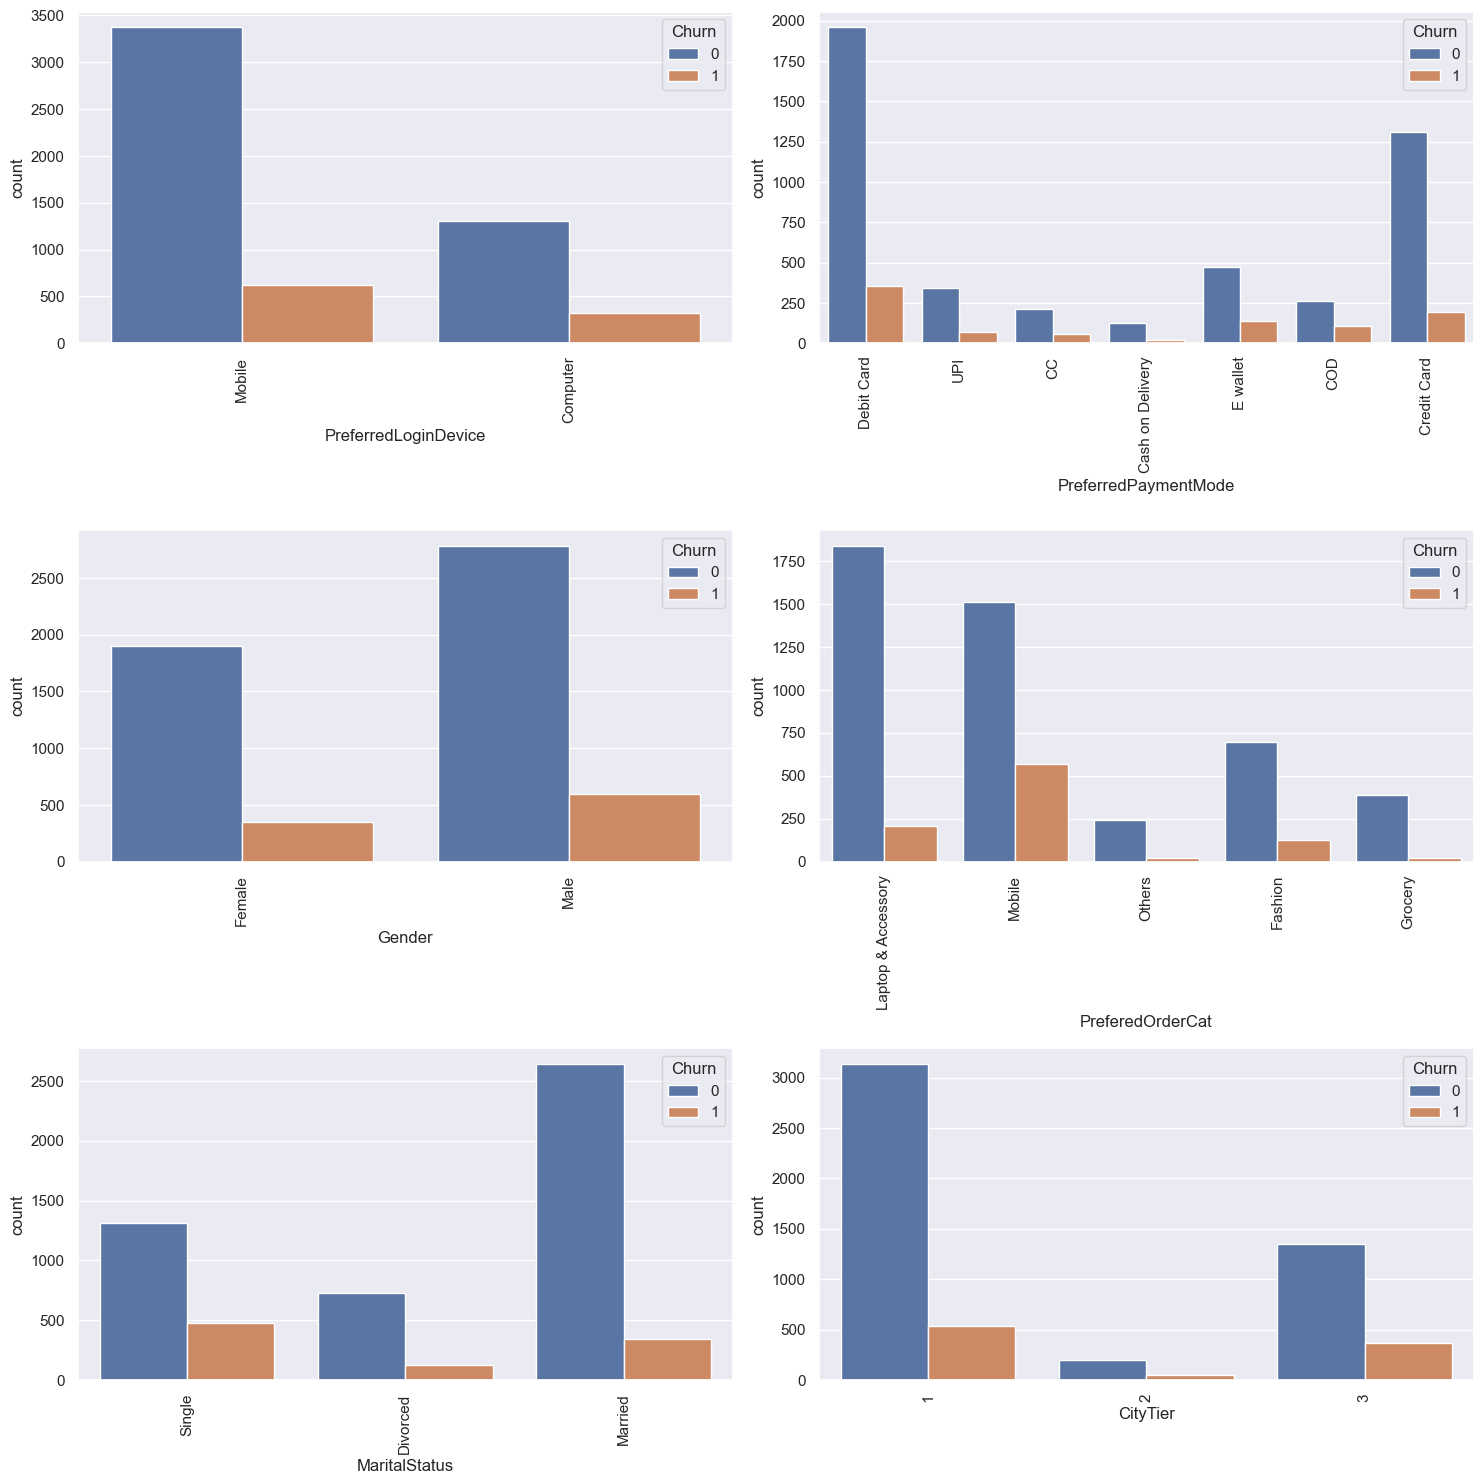

In [131]:
cat_vars = ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
       'PreferedOrderCat', 'MaritalStatus','CityTier']

# create figure with subplots
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
axs = axs.flatten()

# create barplot for each categorical variable
for i, var in enumerate(cat_vars):
    sns.countplot(x=var, hue='Churn', data=df, ax=axs[i])
    axs[i].set_xticks(axs[i].get_xticks())
    axs[i].set_xticklabels(axs[i].get_xticklabels(), rotation=90)

# adjust spacing between subplots
fig.tight_layout()

# show plot
plt.show()

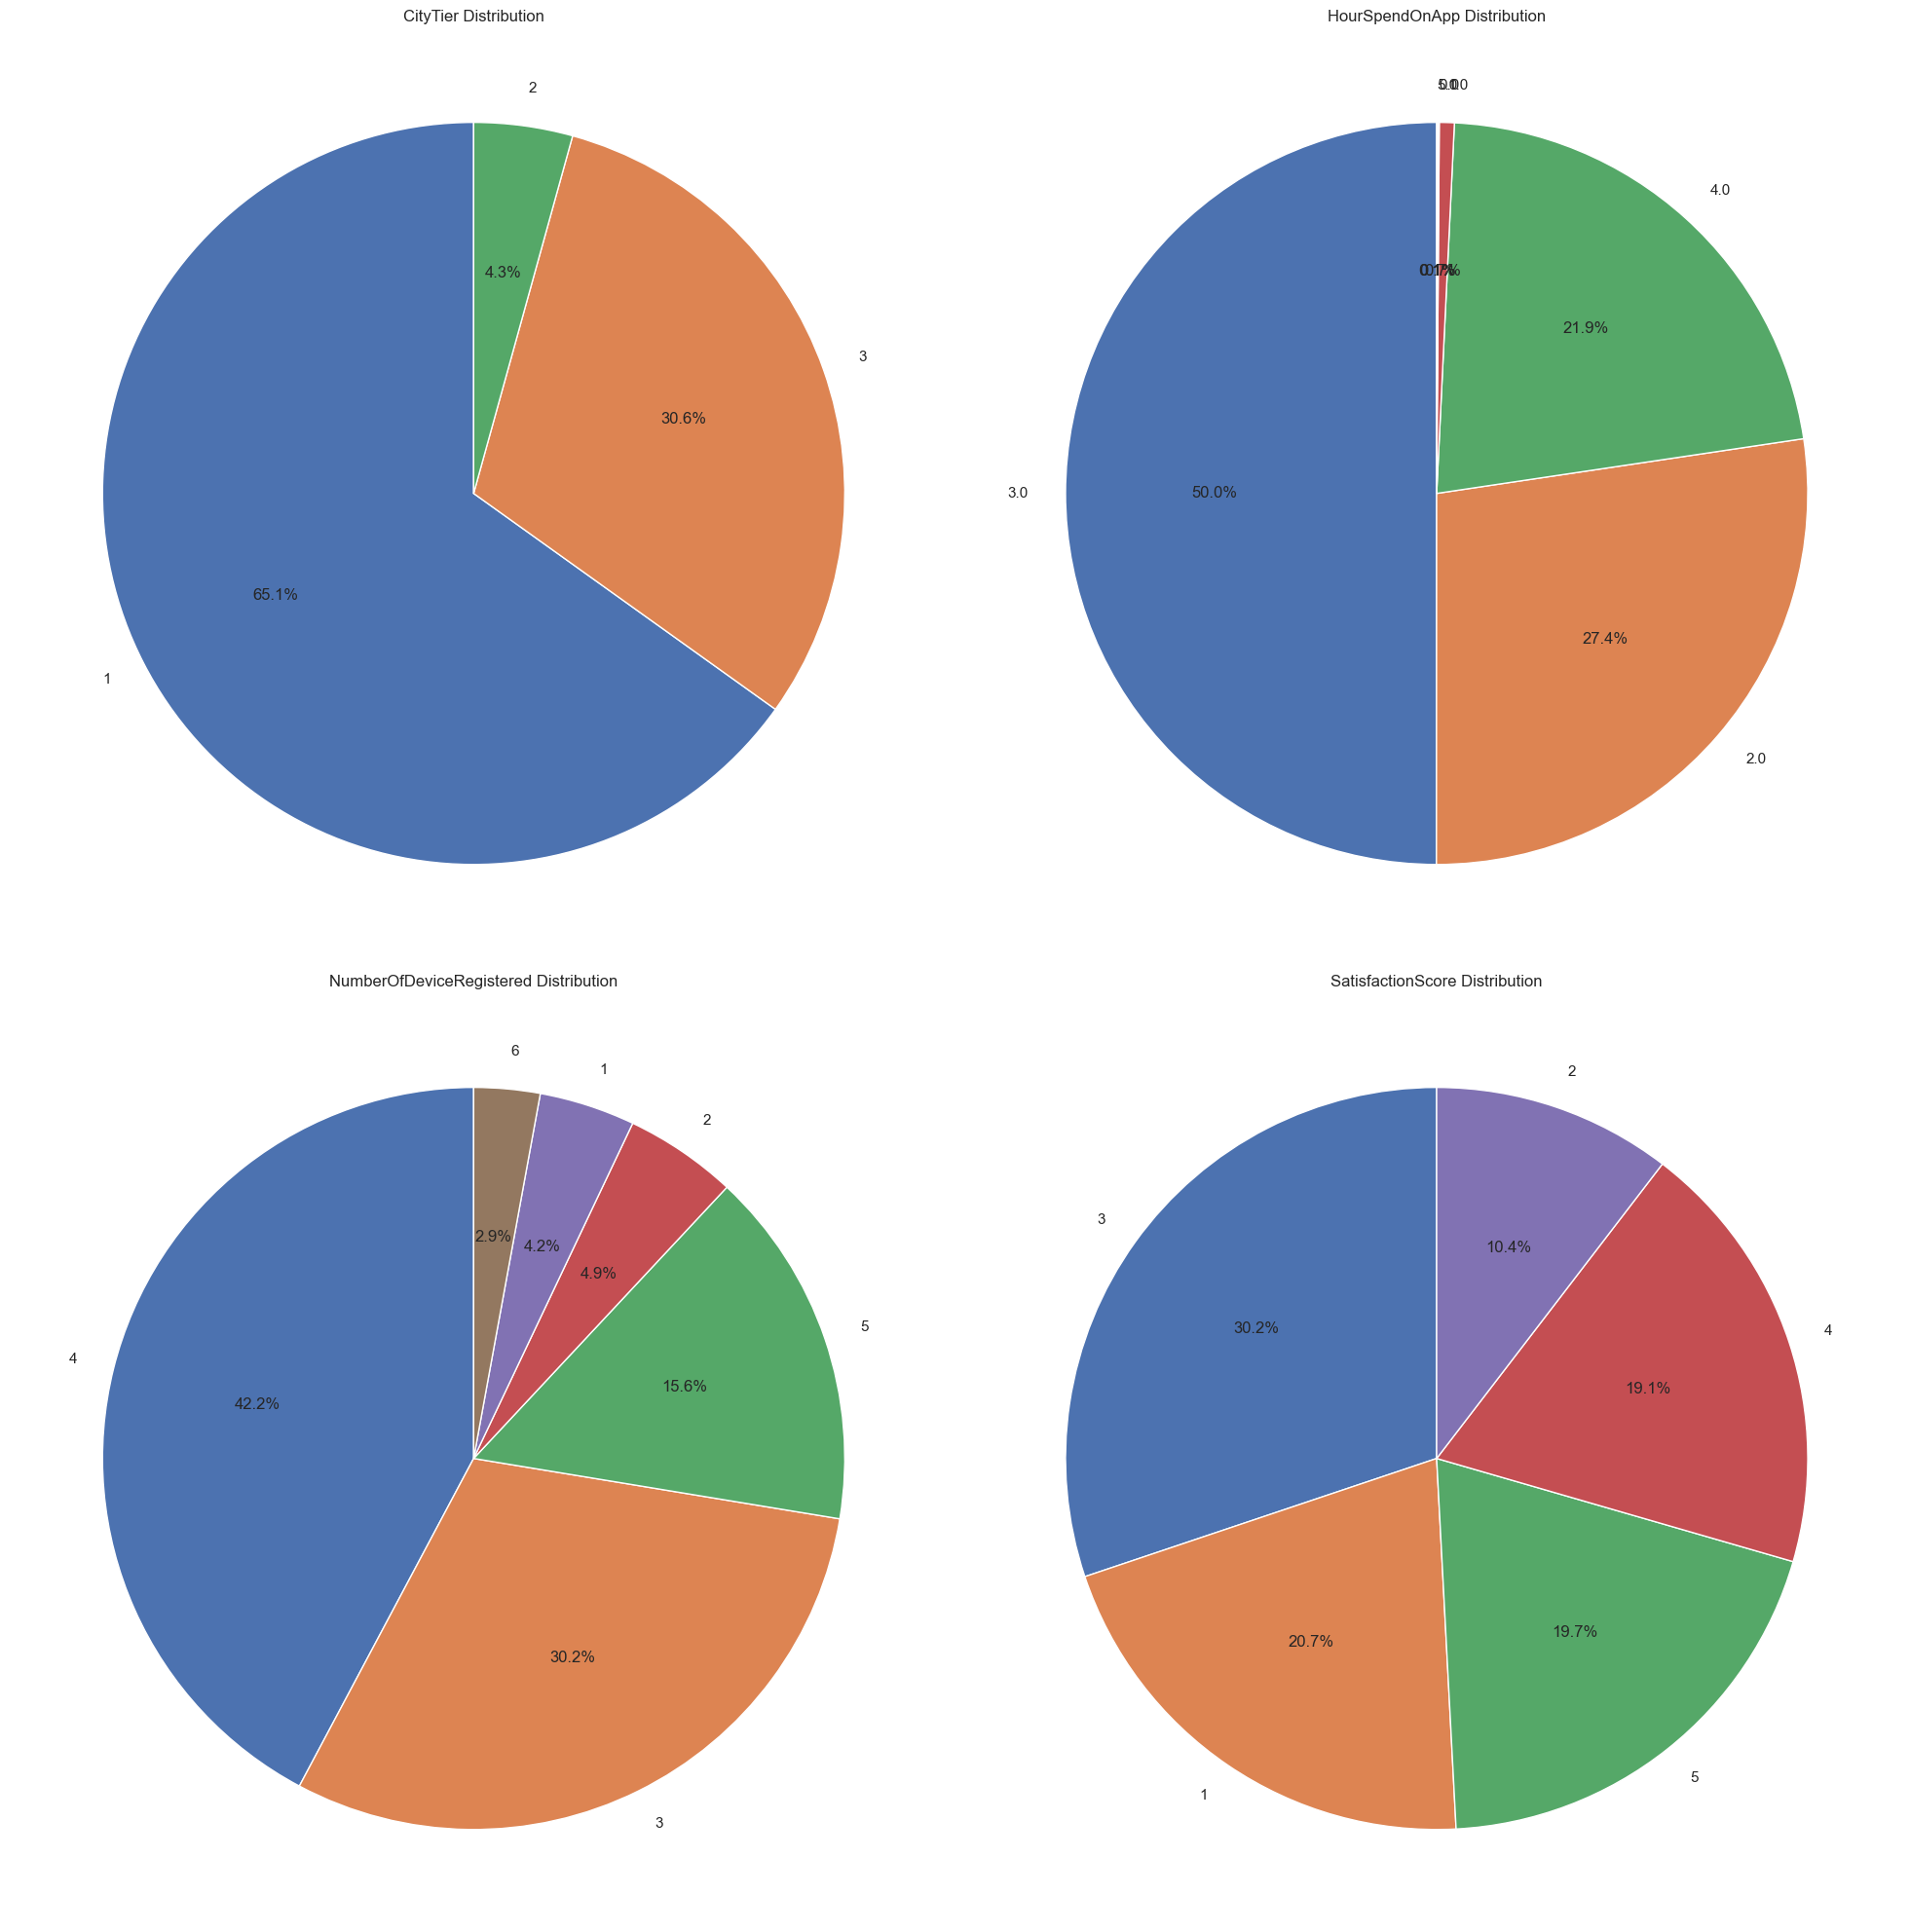

In [132]:
cat_vars = ['CityTier', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore']

# create a figure and axes
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(20, 20))

# create a pie chart for each categorical variable
for i, var in enumerate(cat_vars):
    if i < len(axs.flat):
        # count the number of occurrences for each category
        cat_counts = df[var].value_counts()

        # create a pie chart
        axs.flat[i].pie(cat_counts, labels=cat_counts.index, autopct='%1.1f%%', startangle=90)

        # set a title for each subplot
        axs.flat[i].set_title(f'{var} Distribution')

# adjust spacing between subplots
fig.tight_layout()

# show the plot
plt.show()

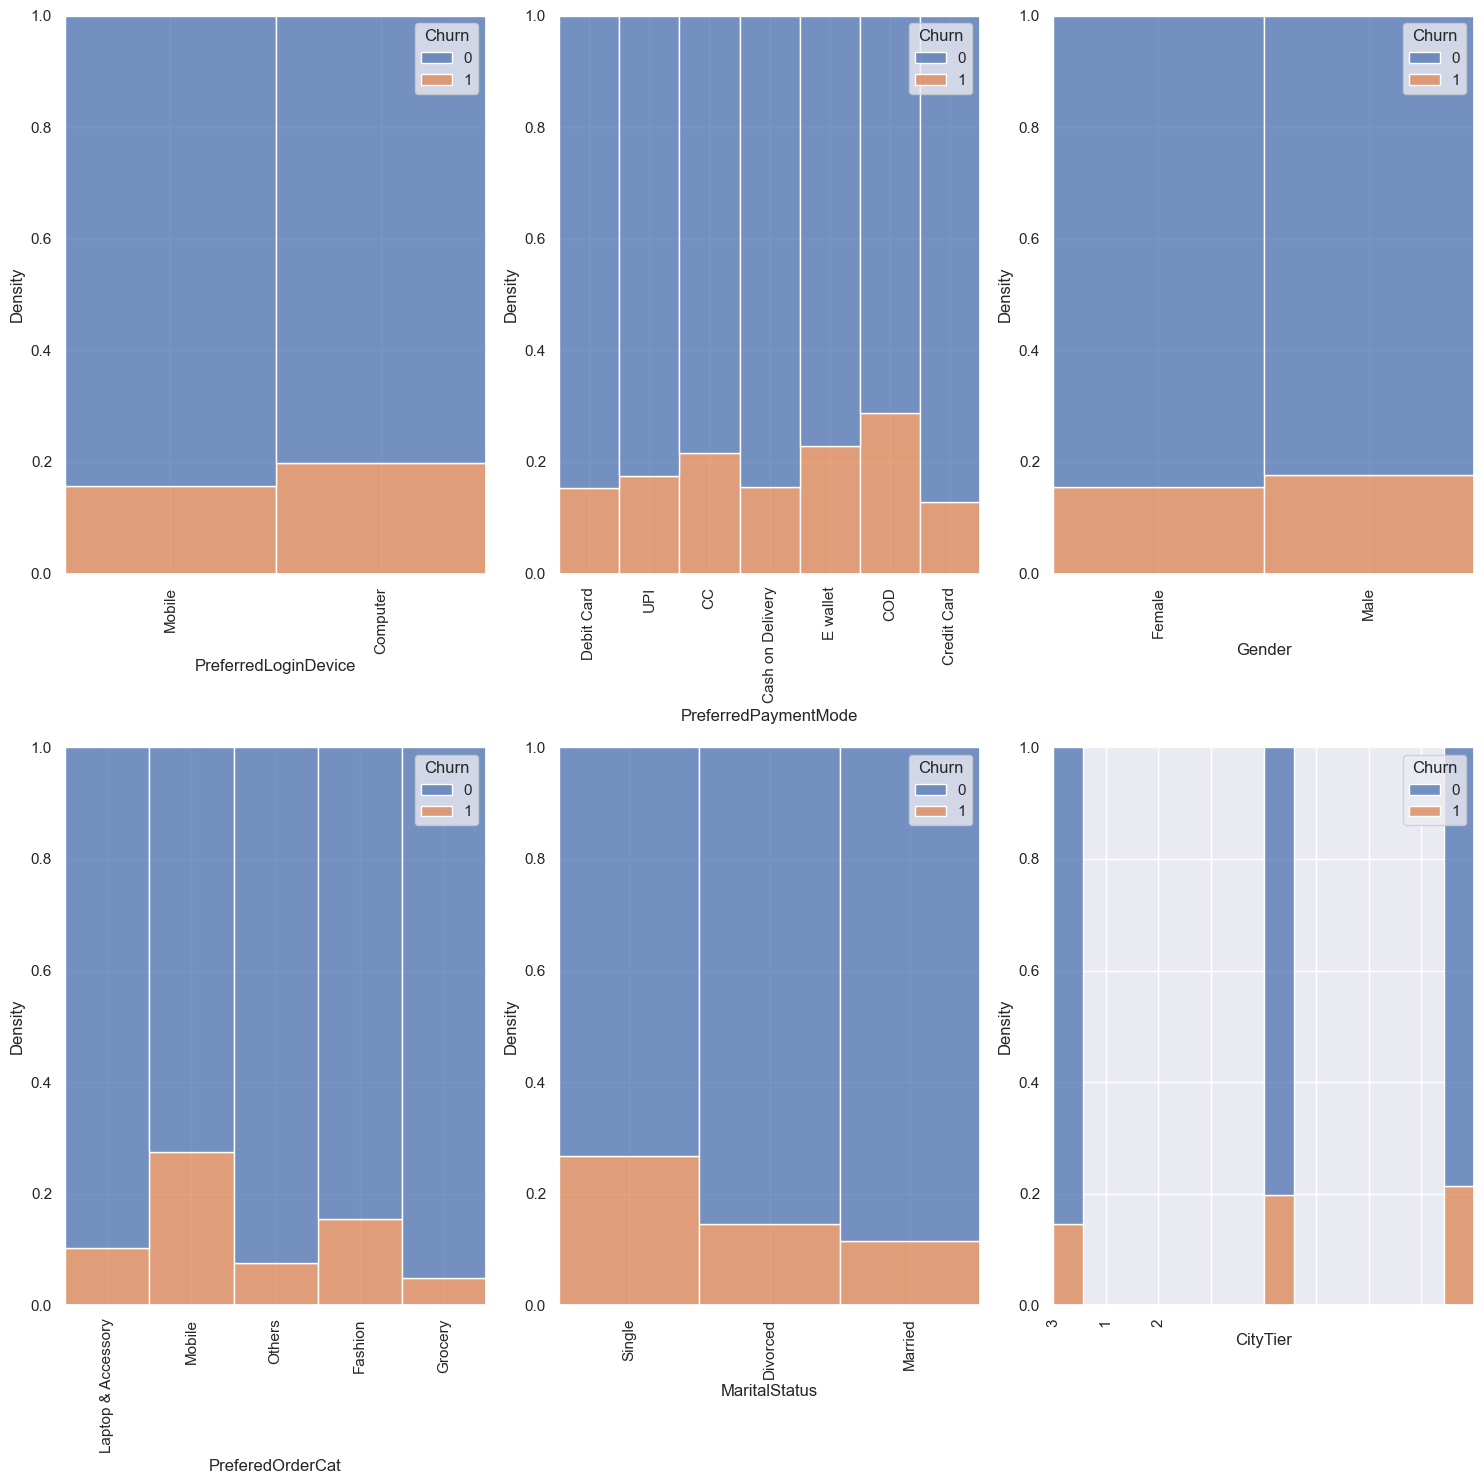

In [134]:
import warnings
warnings.filterwarnings("ignore")
# get list of categorical variables
cat_vars = ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
       'PreferedOrderCat', 'MaritalStatus','CityTier']

# create figure with subplots
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15, 15))
axs = axs.flatten()

# create histplot for each categorical variable
for i, var in enumerate(cat_vars):
    sns.histplot(x=var, hue='Churn', data=df, ax=axs[i], multiple="fill", kde=False, element="bars", fill=True, stat='density')
    axs[i].set_xticklabels(df[var].unique(), rotation=90)
    axs[i].set_xlabel(var)

# adjust spacing between subplots
fig.tight_layout()

# show plot
plt.show()

In [136]:
cat_df = df.select_dtypes(include = ['int64','float64'])

In [139]:
print(cat_df.columns)

Index(['Churn', 'Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress',
       'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')


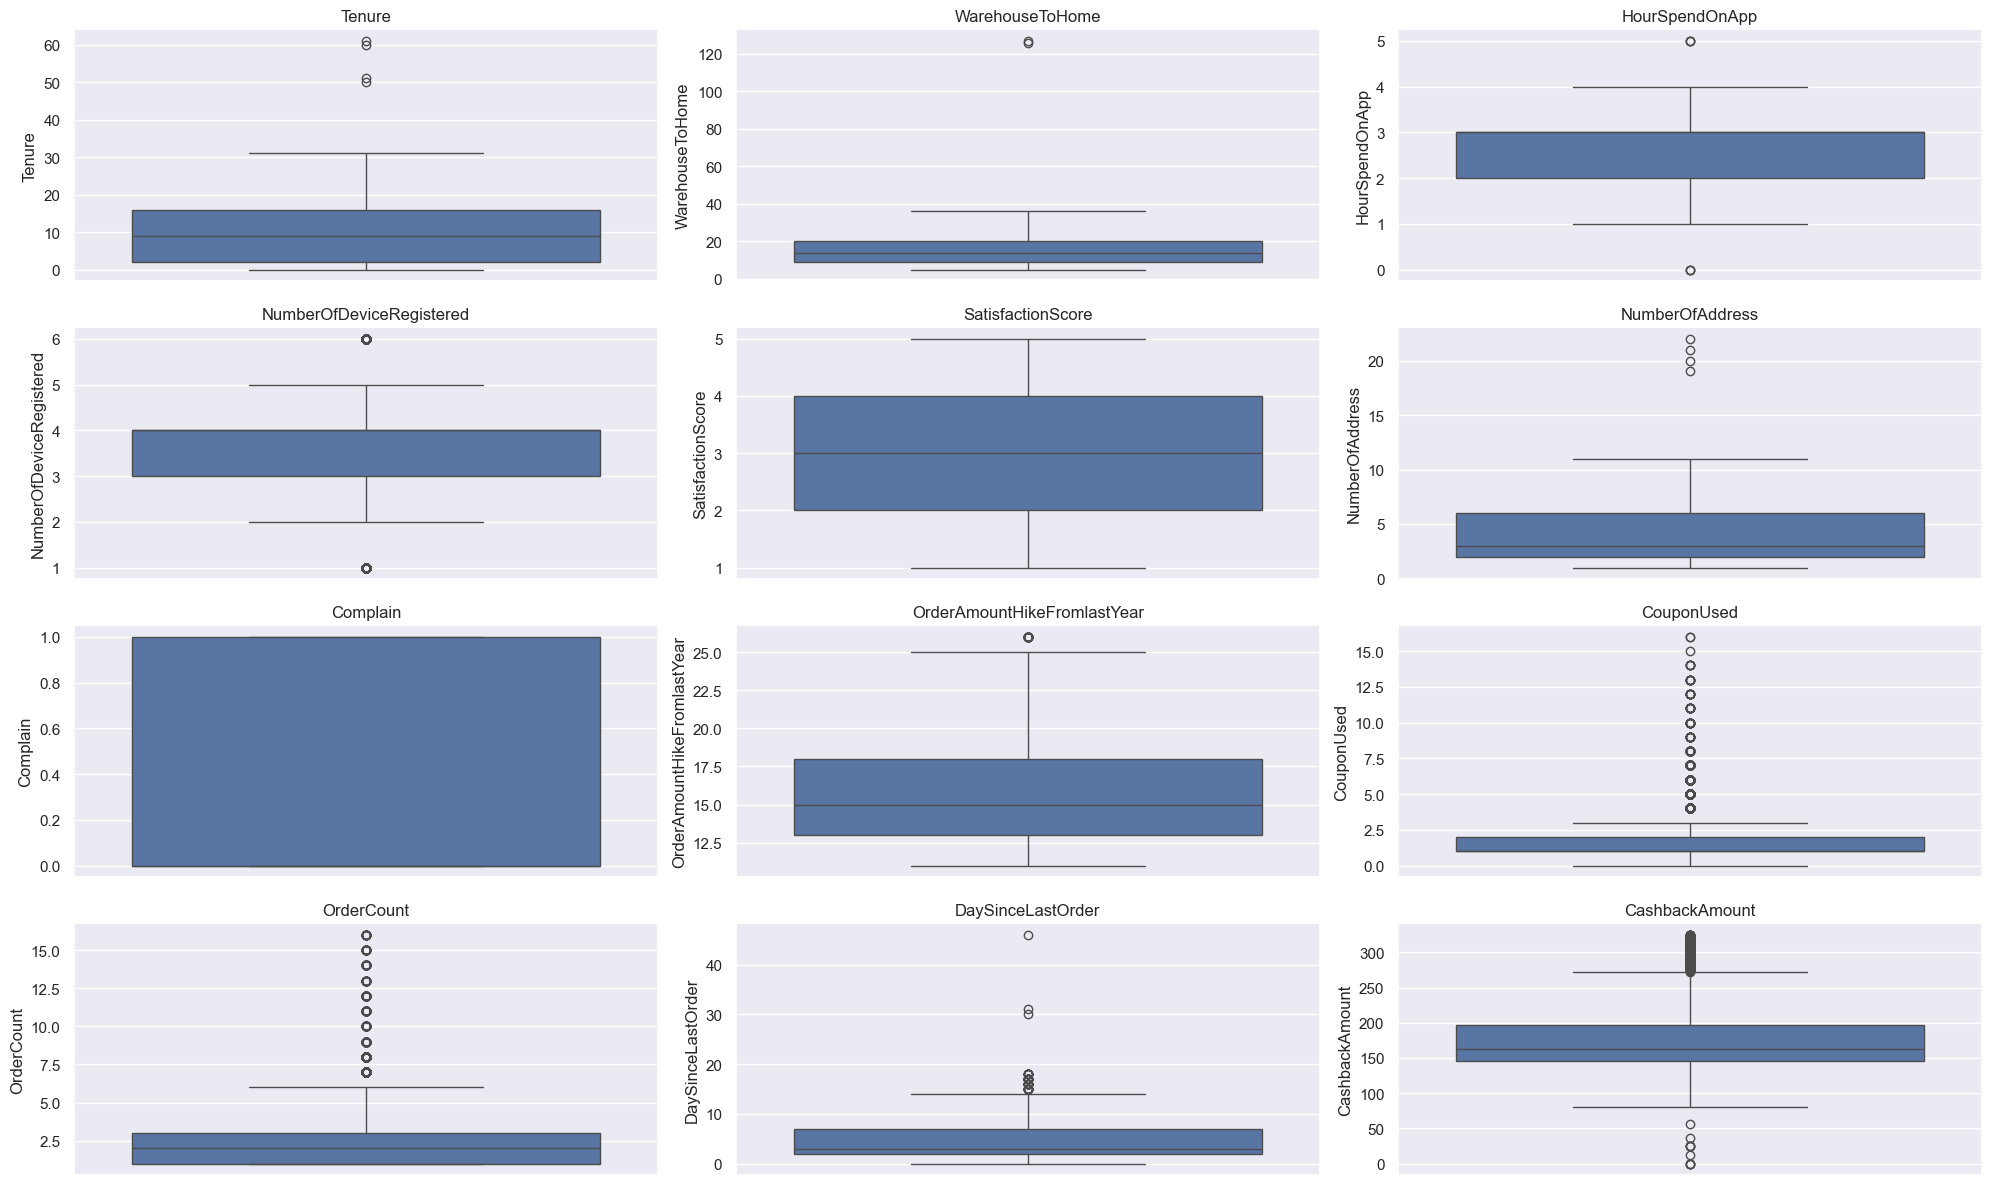

In [141]:
num_vars = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
            'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress',
            'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed',
            'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

fig, axs = plt.subplots(nrows=5, ncols=3, figsize=(20, 15))
axs = axs.flatten()

for i, var in enumerate(num_vars):
    sns.boxplot(y=df[var], ax=axs[i])
    axs[i].set_title(var)

# Remove the extra unused subplots
for j in range(len(num_vars), len(axs)):
    fig.delaxes(axs[j])

fig.tight_layout()
plt.show()

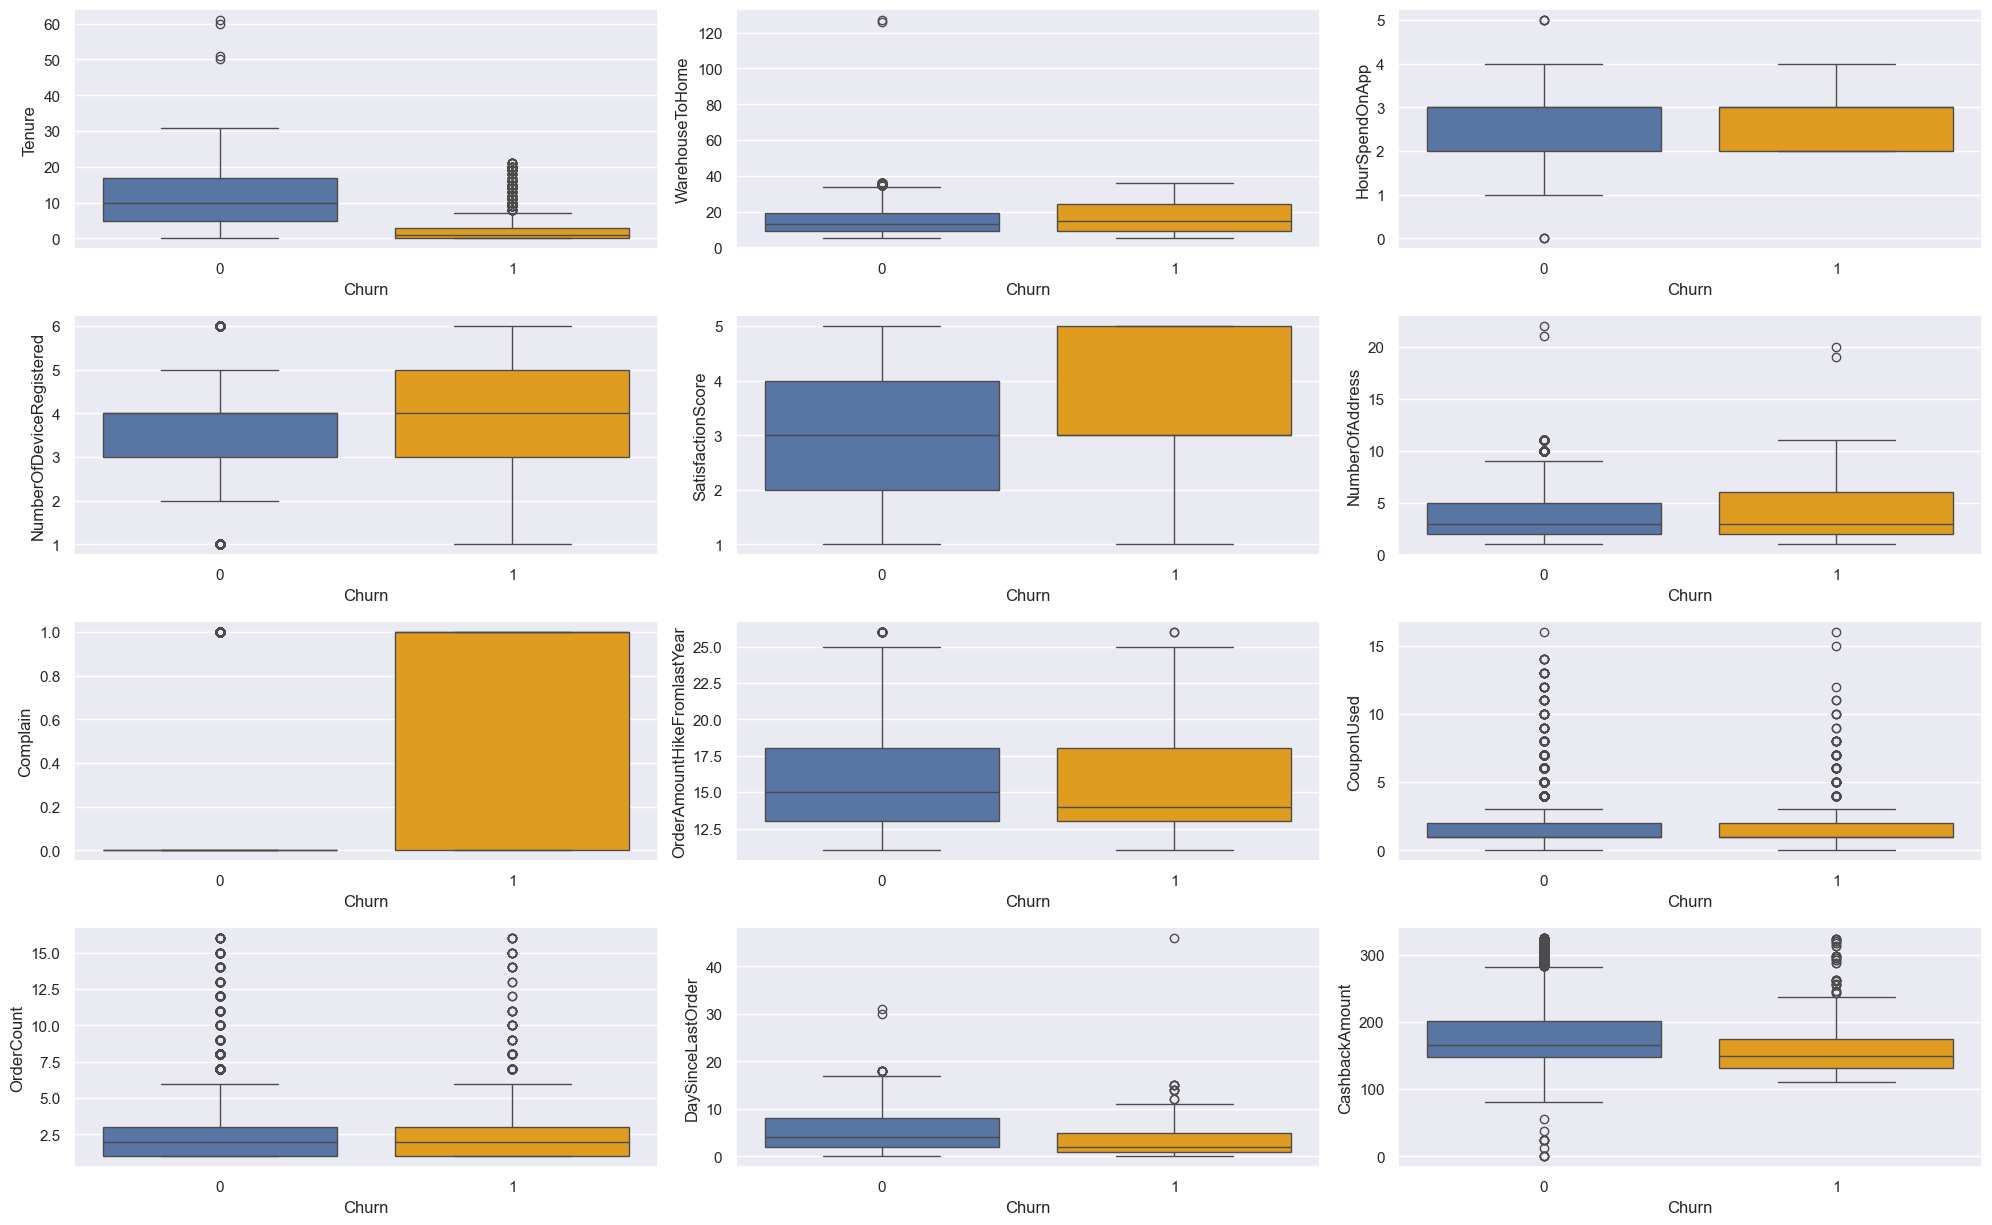

In [142]:
num_vars = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
            'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress',
            'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed',
            'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

fig, axs = plt.subplots(nrows=5, ncols=3, figsize=(20, 15))
axs = axs.flatten()

palette = ["#4C72B0", "orange"]

for i, var in enumerate(num_vars):
    sns.boxplot(y=var, x='Churn', data=df, ax=axs[i], palette=palette)

# Remove the extra unused subplots
for j in range(len(num_vars), len(axs)):
    fig.delaxes(axs[j])

fig.tight_layout()
plt.show()

| Feature            | Importance wrt to Churn |
| ------------------ | ---------- |
| last_purchase_days | Strong     |
| orders_last_12m    | Moderate   |
| support_tickets    | Weak       |
| returns_last_12m   | Weak       |
| avg_order_value    | Weak       |
| discount_rate      | Weak       |
| age                | Weak       |
| tenure_months      | Weak       |

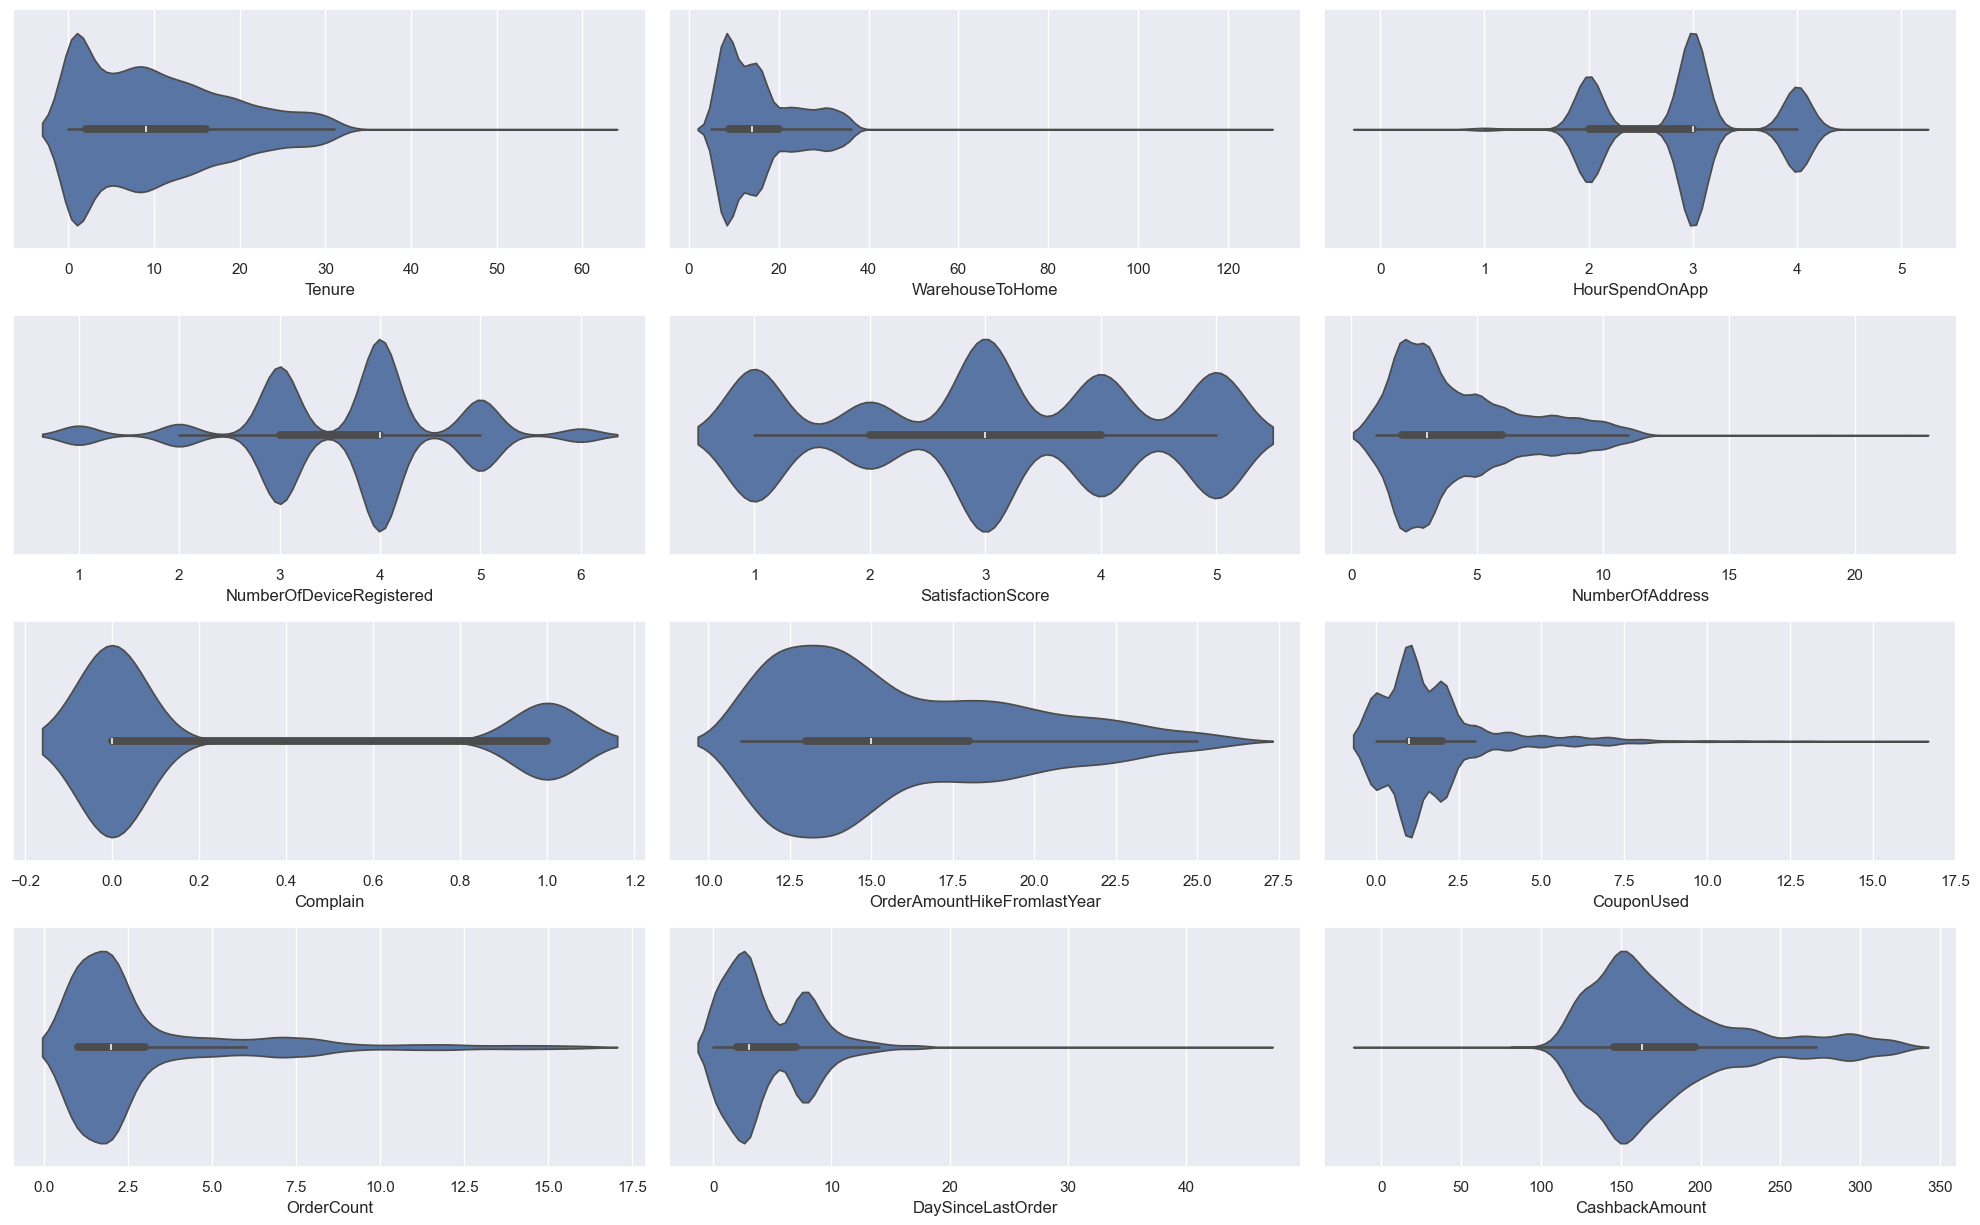

In [145]:
num_vars = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
            'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress',
            'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed',
            'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

fig, axs = plt.subplots(nrows=5, ncols=3, figsize=(20, 15))
axs = axs.flatten()


palette = ["#4C72B0", "orange"]


for i, var in enumerate(num_vars):
    sns.violinplot(x=var, data=df, ax=axs[i])

# Remove the extra unused subplots
for j in range(len(num_vars), len(axs)):
    fig.delaxes(axs[j])


fig.tight_layout()

plt.show()

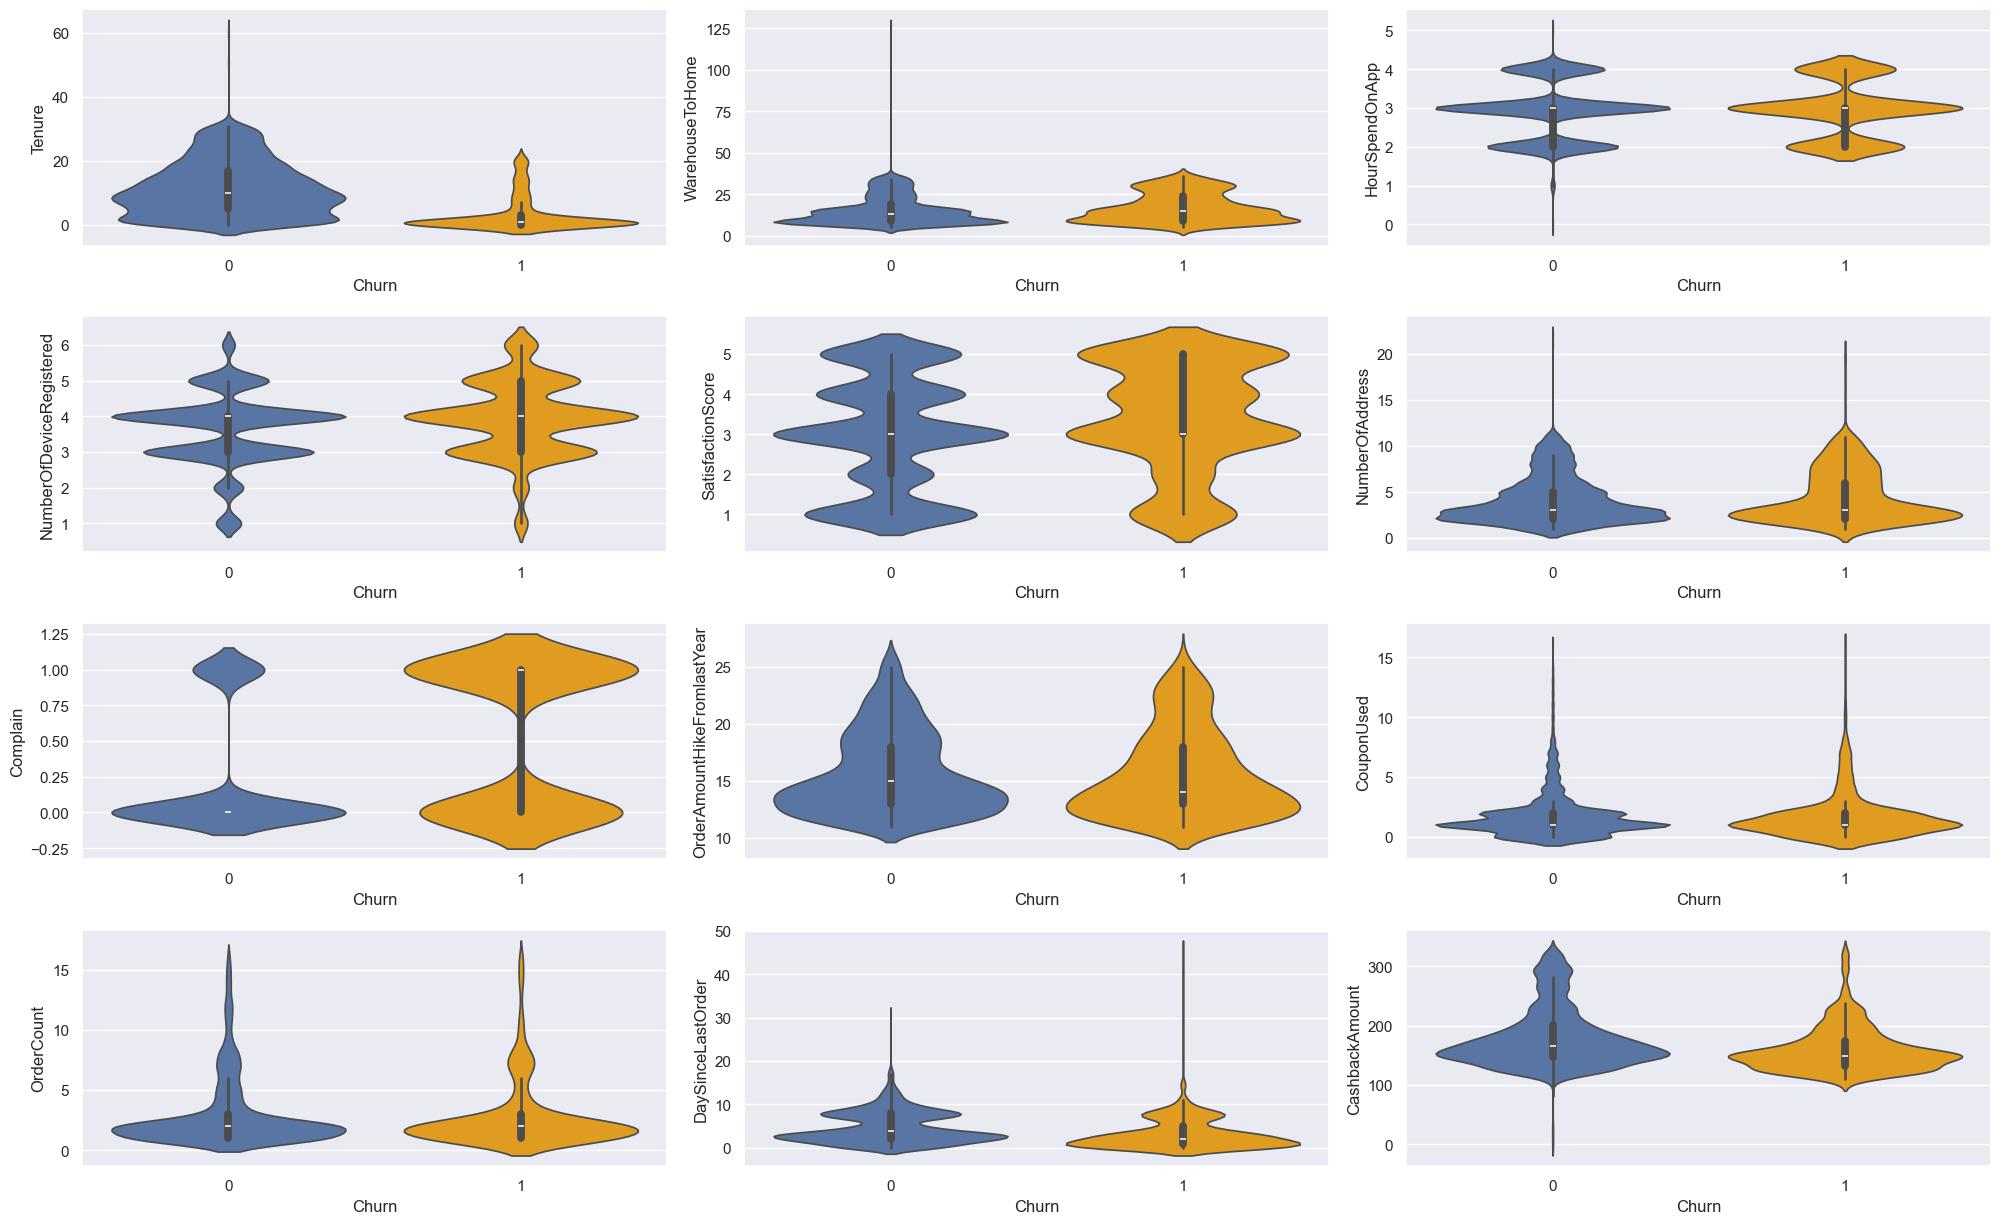

In [147]:
num_vars = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
            'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress',
            'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed',
            'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

fig, axs = plt.subplots(nrows=5, ncols=3, figsize=(20, 15))
axs = axs.flatten()

palette = ["#4C72B0", "orange"]

for i, var in enumerate(num_vars):
    sns.violinplot(y=var, x='Churn', data=df, ax=axs[i], palette=palette)

# Remove the extra unused subplots
for j in range(len(num_vars), len(axs)):
    fig.delaxes(axs[j])


fig.tight_layout()

plt.show()

## Bivariate Analysis

### Scatter Plot Analysis

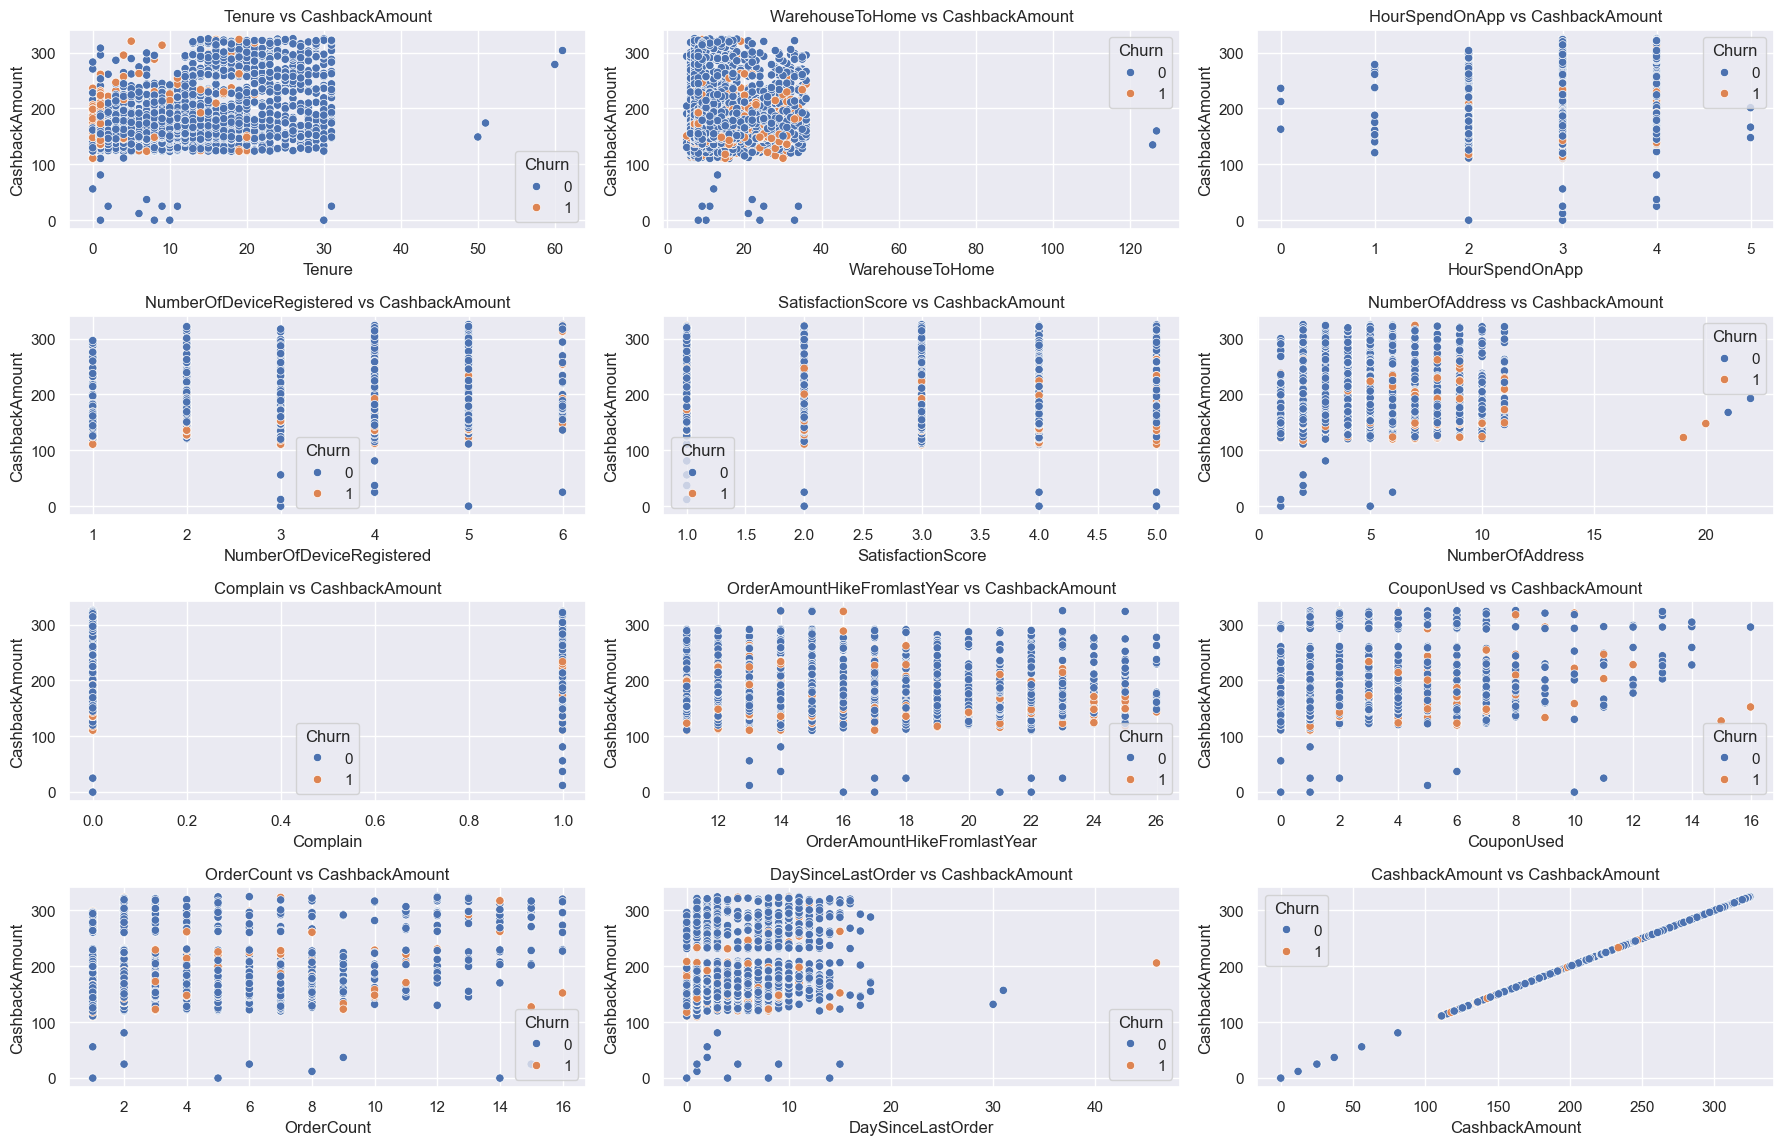

In [151]:
x_vars = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
            'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress',
            'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed',
            'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

fig, axs = plt.subplots(nrows=5, ncols=3, figsize=(18, 14))
axs = axs.flatten()

for i, var in enumerate(x_vars):
    sns.scatterplot(
        x=var,
        y='CashbackAmount',
        hue='Churn',
        data=df,
        ax=axs[i]
    )
    axs[i].set_title(f'{var} vs CashbackAmount')

# Remove the extra unused subplots
for j in range(len(num_vars), len(axs)):
    fig.delaxes(axs[j])


plt.tight_layout()
plt.show()

Scatter plots revealed that behavioral variables such as purchase frequency have some relationship with inactivity, while demographic and monetary variables show little association. This suggests that Churn in this dataset is primarily driven by declining engagement rather than customer characteristics or spending power.

### Correlation Heat Map

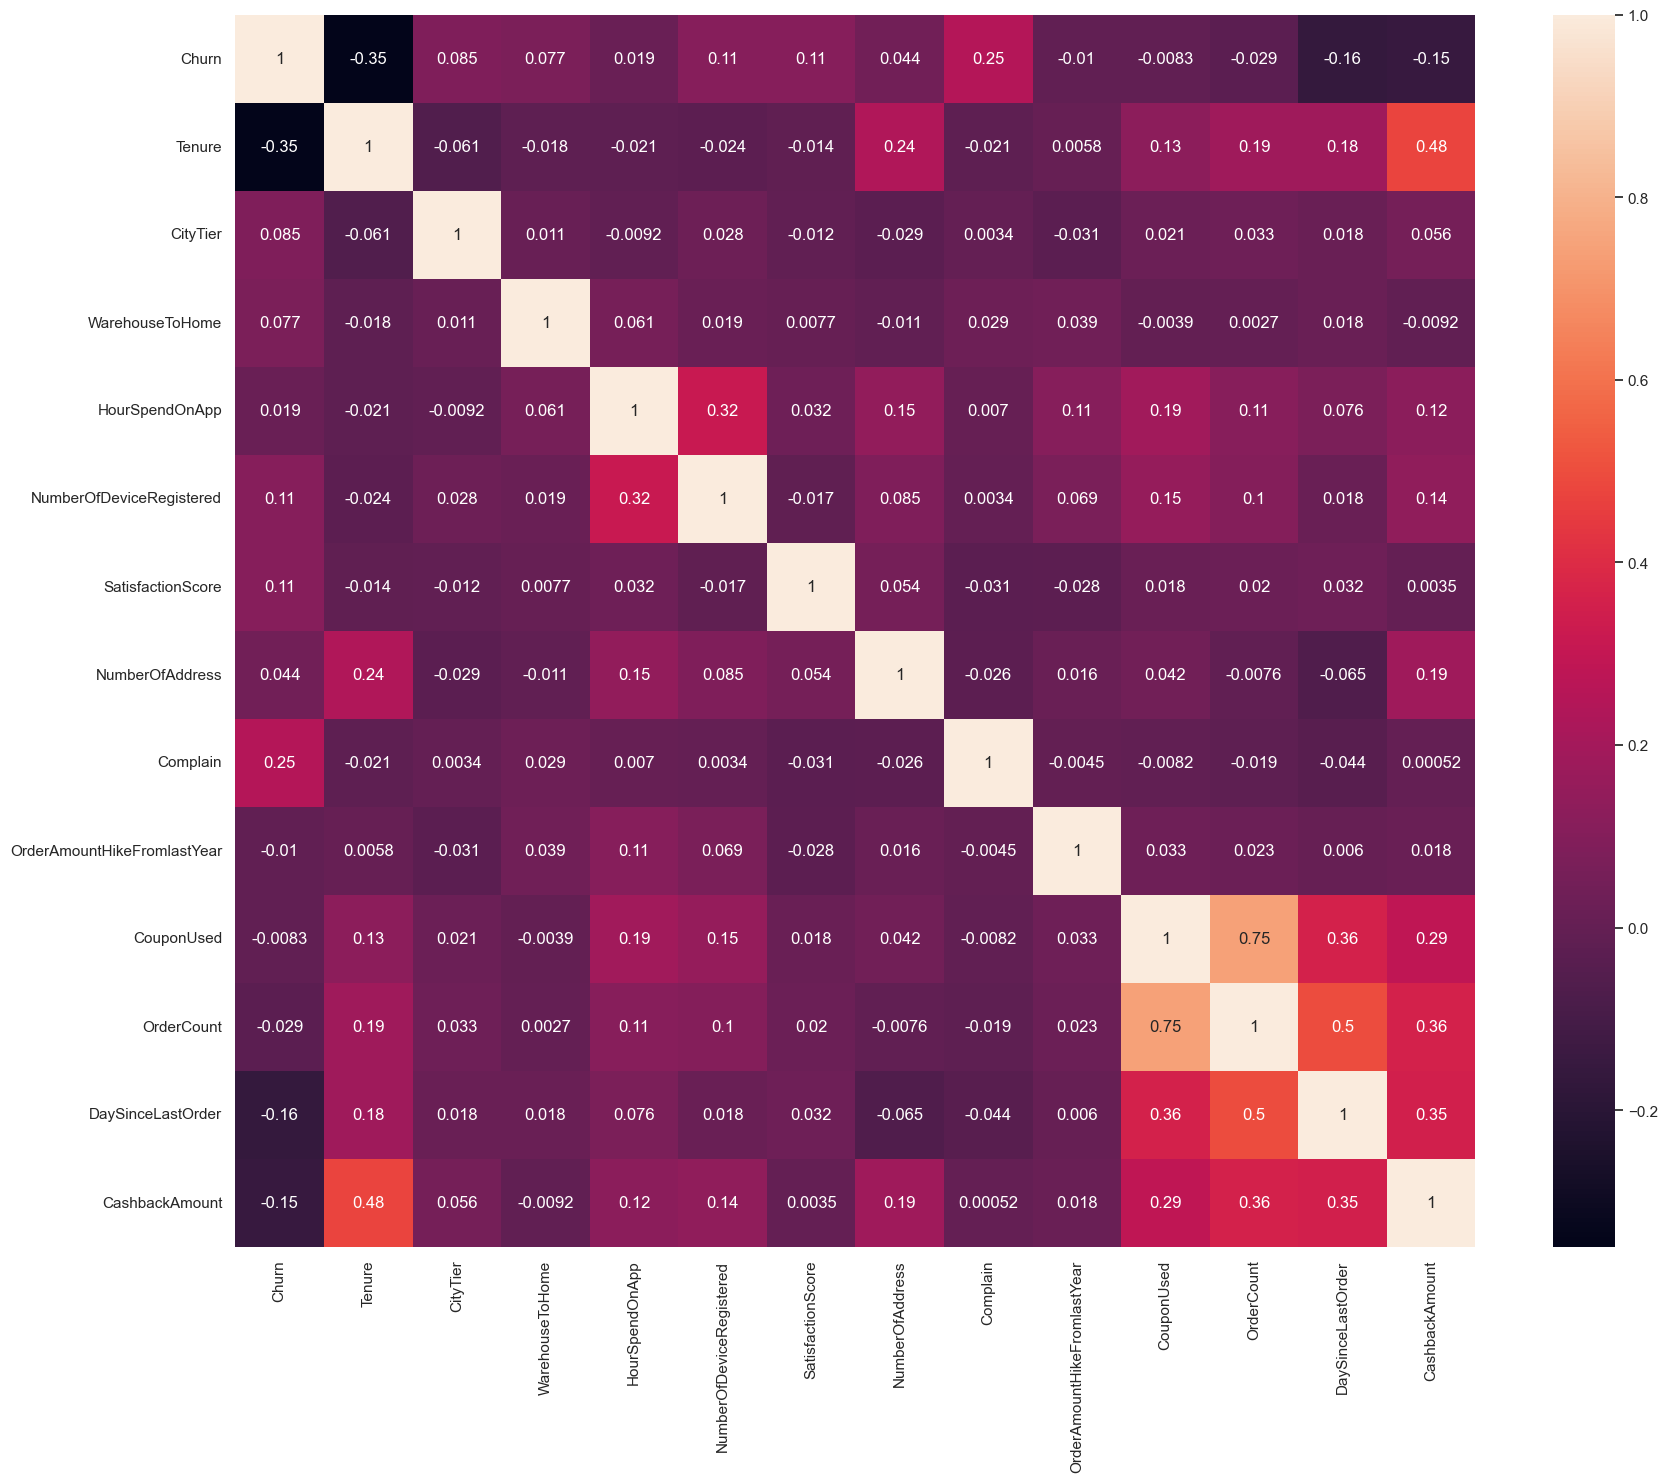

In [155]:
# Correlation Heatmap (Correct)
plt.figure(figsize=(20, 16))
sns.heatmap(df.select_dtypes(include=['number']).corr(), fmt='.2g', annot=True)
plt.show()

# Data Preprocessing

In [159]:
from sklearn import preprocessing

# Loop over each column in the DataFrame where dtype is 'object'
for col in df.select_dtypes(include=['object']).columns:
    
    # Initialize a LabelEncoder object
    label_encoder = preprocessing.LabelEncoder()
    
    # Fit the encoder to the unique values in the column
    label_encoder.fit(df[col].unique())
    
    # Transform the column using the encoder
    df[col] = label_encoder.transform(df[col])
    
    # Print the column name and the unique encoded values
    print(f"{col}: {df[col].unique()}")

PreferredLoginDevice: [1 0]
PreferredPaymentMode: [4 6 0 2 5 1 3]
Gender: [0 1]
PreferedOrderCat: [2 3 4 0 1]
MaritalStatus: [2 0 1]


In [161]:
# Check missing value
missing = df.isnull().sum()*100 / df.shape[0]
missing[missing > 0].sort_values(ascending=False)
print(missing)

Churn                          0.000000
Tenure                         4.689165
PreferredLoginDevice           0.000000
CityTier                       0.000000
WarehouseToHome                4.458259
PreferredPaymentMode           0.000000
Gender                         0.000000
HourSpendOnApp                 4.529307
NumberOfDeviceRegistered       0.000000
PreferedOrderCat               0.000000
SatisfactionScore              0.000000
MaritalStatus                  0.000000
NumberOfAddress                0.000000
Complain                       0.000000
OrderAmountHikeFromlastYear    4.706927
CouponUsed                     4.547069
OrderCount                     4.582593
DaySinceLastOrder              5.452931
CashbackAmount                 0.000000
dtype: float64


# Train Test Split

In [164]:
from sklearn.model_selection import train_test_split
# Select the features (X) and the target variable (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Outlier Treatment

In [167]:
cols = [
'DaySinceLastOrder',
'OrderAmountHikeFromlastYear',
'Tenure',
'OrderCount',
'CouponUsed',
'HourSpendOnApp',
'WarehouseToHome'
]

# Compute median from training data only
median_value = X_train[cols].median()

# Apply to both datasets
X_train[cols] = X_train[cols].fillna(median_value)
X_test[cols] = X_test[cols].fillna(median_value)

In [169]:
#Check missing value in each
print(X_train.isnull().sum())
print(X_test.isnull().sum())

Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress               

In [171]:
#Remove Extreme Outliers
outlier_cols_remove = ['WarehouseToHome', 'DaySinceLastOrder']

iqr_bounds = {}

for col in outlier_cols_remove:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    iqr_bounds[col] = (lower, upper)

# Remove rows from training set only
for col, (lower, upper) in iqr_bounds.items():
    mask = (X_train[col] >= lower) & (X_train[col] <= upper)
    X_train = X_train[mask]
    y_train = y_train[mask]

In [173]:
#Cap Long-Tail Variables
outlier_cols_cap = ['CouponUsed', 'OrderCount', 'CashbackAmount']

cap_bounds = {}

for col in outlier_cols_cap:
    lower = X_train[col].quantile(0.01)
    upper = X_train[col].quantile(0.90)
    
    cap_bounds[col] = (lower, upper)

for col, (lower, upper) in cap_bounds.items():
    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col]  = X_test[col].clip(lower, upper)

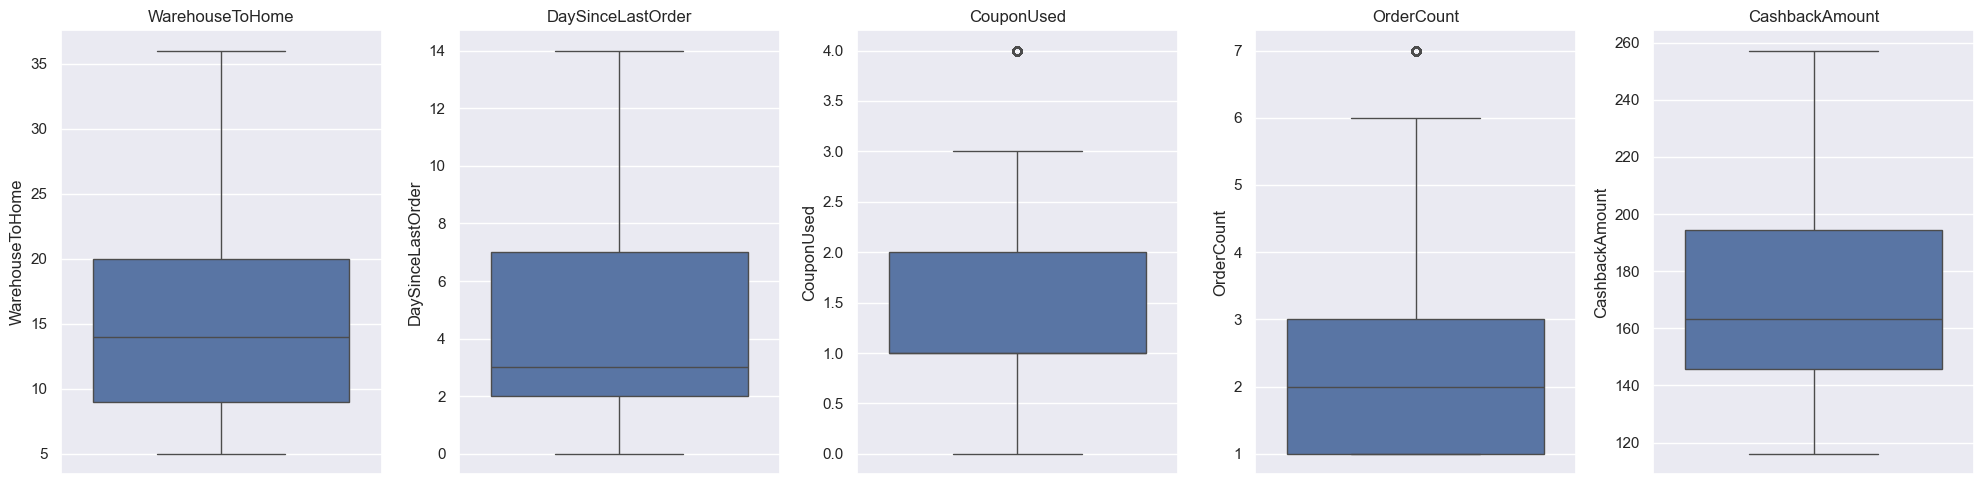

In [175]:
import seaborn as sns
import matplotlib.pyplot as plt

cols_check = ['WarehouseToHome','DaySinceLastOrder','CouponUsed','OrderCount','CashbackAmount']

fig, axs = plt.subplots(1,5,figsize=(20,5))

for i, col in enumerate(cols_check):
    sns.boxplot(y=X_train[col], ax=axs[i])
    axs[i].set_title(col)

plt.tight_layout()
plt.show()

# Feature Engineering

In [178]:
# Engagement score
X_train["engagement_score"] = X_train["OrderCount"] / (X_train["Tenure"] + 1)
X_test["engagement_score"]  = X_test["OrderCount"] / (X_test["Tenure"] + 1)

# Complaint rate
X_train["complaint_rate"] = X_train["Complain"] / (X_train["OrderCount"] + 1)
X_test["complaint_rate"]  = X_test["Complain"] / (X_test["OrderCount"] + 1)

# Recency ratio
X_train["recency_ratio"] = X_train["DaySinceLastOrder"] / (X_train["Tenure"] + 1)
X_test["recency_ratio"]  = X_test["DaySinceLastOrder"] / (X_test["Tenure"] + 1)

In [180]:
X_test.head()

,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,...,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,engagement_score,complaint_rate,recency_ratio
4331,1.0,0,3,7.0,1,0,4.0,6,3,5,...,2,0,22.0,2.0,2.0,1.0,148.25,1.000000,0.000000,0.500000
1988,15.0,1,1,9.0,4,0,3.0,1,2,1,...,3,1,13.0,1.0,1.0,3.0,152.31,0.062500,0.500000,0.187500
3443,13.0,0,1,29.0,3,0,3.0,4,0,5,...,3,1,14.0,2.0,2.0,9.0,233.80,0.142857,0.333333,0.642857
4559,5.0,1,1,7.0,4,1,4.0,5,3,5,...,3,0,13.0,4.0,4.0,3.0,147.18,0.666667,0.000000,0.500000
4898,13.0,1,1,7.0,4,0,4.0,5,1,1,...,3,0,17.0,4.0,2.0,9.0,252.42,0.142857,0.000000,0.642857


In [182]:
X_train.head()

,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,...,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,engagement_score,complaint_rate,recency_ratio
4478,1.0,1,1,12.0,4,0,3.0,4,3,4,...,3,1,13.0,1.0,2.0,3.0,149.78,1.000000,0.333333,1.5
3685,17.0,1,1,13.0,3,0,4.0,5,2,3,...,3,1,15.0,2.0,2.0,9.0,165.81,0.111111,0.333333,0.5
731,0.0,1,1,9.0,4,1,3.0,4,3,3,...,2,0,12.0,0.0,1.0,2.0,130.33,1.000000,0.000000,2.0
291,9.0,0,1,8.0,4,1,2.0,3,3,2,...,2,1,23.0,1.0,1.0,0.0,117.02,0.100000,0.500000,0.0
184,4.0,1,1,11.0,1,1,2.0,3,3,2,...,1,1,12.0,0.0,1.0,3.0,148.21,0.200000,0.500000,0.6


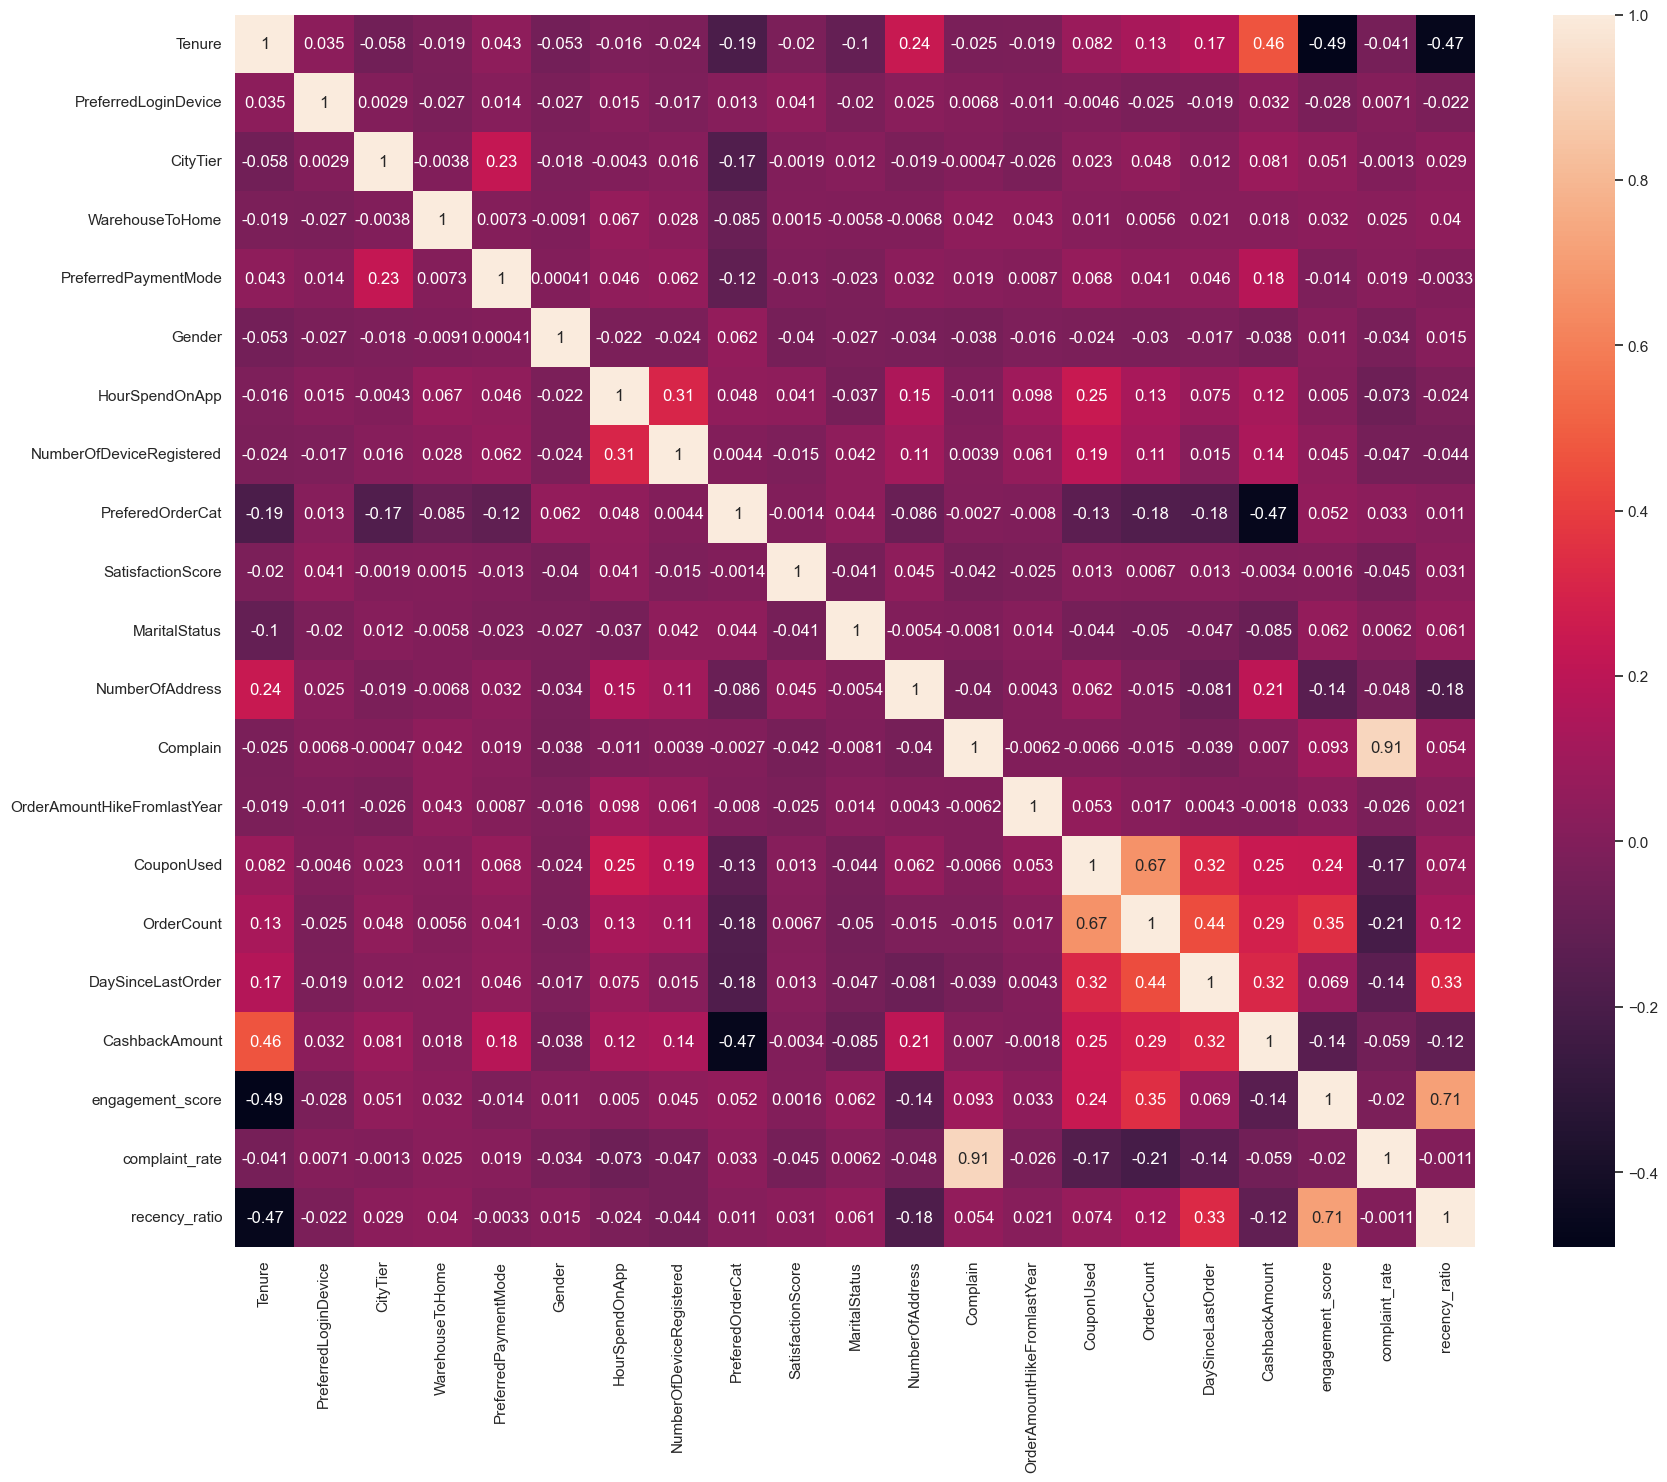

In [184]:
# Correlation Heatmap (Correct)
plt.figure(figsize=(20, 16))
sns.heatmap(X_train.select_dtypes(include=['number']).corr(), fmt='.2g', annot=True)
plt.show()

# Model Building

# Decision Tree Model

In [188]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
dtree = DecisionTreeClassifier(class_weight='balanced')
param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [1, 2, 3, 4],
    'random_state': [0, 42]
}

## Hyperparameter Tuning

In [191]:
# Perform a grid search with cross-validation to find the best hyperparameters
grid_search = GridSearchCV(dtree, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Print the best hyperparameters
print(grid_search.best_params_)

{'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'random_state': 42}


In [193]:
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier(random_state=42, max_depth=8, min_samples_leaf=1, min_samples_split=2, class_weight='balanced')
dtree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


## Model Evaluation

In [196]:
from sklearn.metrics import accuracy_score
y_pred = dtree.predict(X_test)
print("Accuracy Score :", round(accuracy_score(y_test, y_pred)*100 ,2), "%")

Accuracy Score : 87.66 %


In [198]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,  jaccard_score, log_loss

print("Accuracy:", round(accuracy_score(y_test, y_pred)*100 ,5), "%")
print("Precision:", round(precision_score(y_test, y_pred)*100 ,5), "%")
print("Recall:", round(recall_score(y_test, y_pred)*100 ,5), "%")
print("F1 Score:", round(f1_score(y_test, y_pred)*100 ,5), "%")
print("Jaccard Score:", round(jaccard_score(y_test, y_pred)*100 ,5), "%")
print("Log Loss:", log_loss(y_test, y_pred))

Accuracy: 87.65542 %
Precision: 58.27338 %
Recall: 87.56757 %
F1 Score: 69.9784 %
Jaccard Score: 53.8206 %
Log Loss: 4.44943856224448


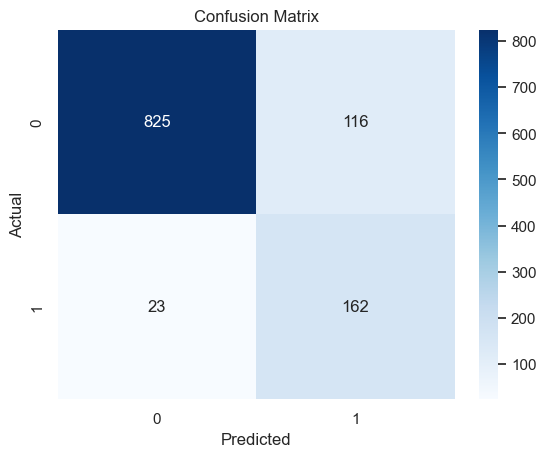

In [200]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

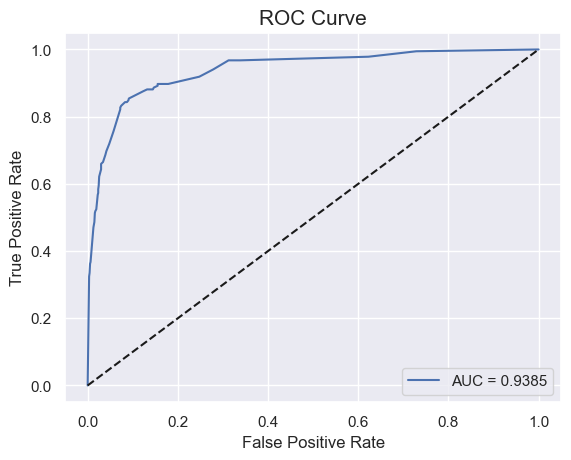

In [202]:
from sklearn.metrics import roc_curve, roc_auc_score
y_pred_proba = dtree.predict_proba(X_test)[:][:,1]

df_actual_predicted = pd.concat([pd.DataFrame(np.array(y_test), columns=['y_actual']), pd.DataFrame(y_pred_proba, columns=['y_pred_proba'])], axis=1)
df_actual_predicted.index = y_test.index

fpr, tpr, tr = roc_curve(df_actual_predicted['y_actual'], df_actual_predicted['y_pred_proba'])
auc = roc_auc_score(df_actual_predicted['y_actual'], df_actual_predicted['y_pred_proba'])

plt.plot(fpr, tpr, label='AUC = %0.4f' %auc)
plt.plot(fpr, fpr, linestyle = '--', color='k')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', size = 15)
plt.legend()

# Random Forest

In [205]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
rfc = RandomForestClassifier(class_weight='balanced')
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'max_features': ['sqrt', 'log2', None],
    'random_state': [0, 42]
}

## Hyperparameter Tuning

In [208]:
# Perform a grid search with cross-validation to find the best hyperparameters
grid_search = GridSearchCV(rfc, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Print the best hyperparameters
print(grid_search.best_params_)

{'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200, 'random_state': 42}


In [210]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(random_state=0, max_features='sqrt', n_estimators=100, class_weight='balanced')
rfc.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Model Evaluation

In [213]:
y_pred = rfc.predict(X_test)
print("Accuracy Score :", round(accuracy_score(y_test, y_pred)*100 ,2), "%")

Accuracy Score : 97.87 %


In [215]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,  jaccard_score, log_loss

print("Accuracy:", round(accuracy_score(y_test, y_pred)*100 ,5), "%")
print("Precision:", round(precision_score(y_test, y_pred)*100 ,5), "%")
print("Recall:", round(recall_score(y_test, y_pred)*100 ,5), "%")
print("F1 Score:", round(f1_score(y_test, y_pred)*100 ,5), "%")
print("Jaccard Score:", round(jaccard_score(y_test, y_pred)*100 ,5), "%")
print("Log Loss:", log_loss(y_test, y_pred))

Accuracy: 97.86856 %
Precision: 99.3865 %
Recall: 87.56757 %
F1 Score: 93.10345 %
Jaccard Score: 87.09677 %
Log Loss: 0.7682483848479679


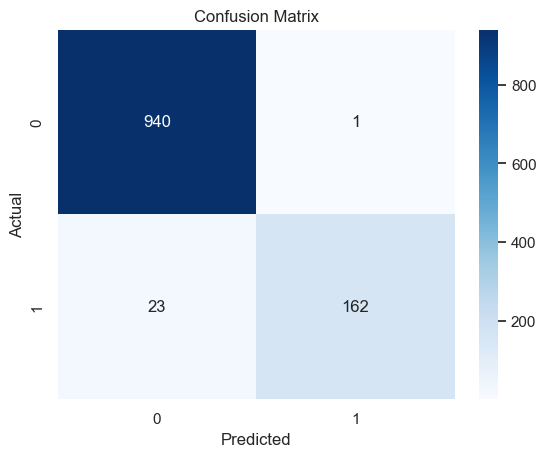

In [217]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

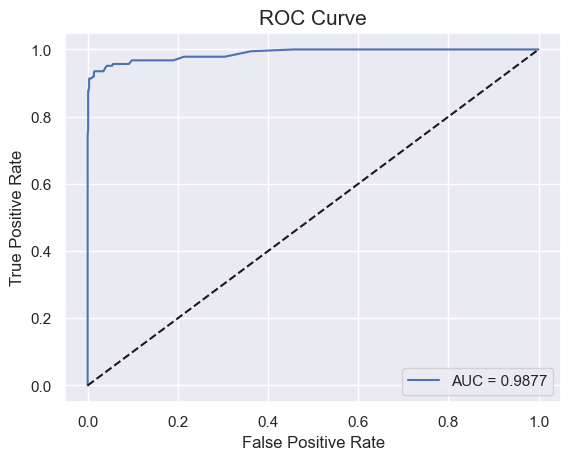

In [219]:
from sklearn.metrics import roc_curve, roc_auc_score
y_pred_proba = rfc.predict_proba(X_test)[:][:,1]

df_actual_predicted = pd.concat([pd.DataFrame(np.array(y_test), columns=['y_actual']), pd.DataFrame(y_pred_proba, columns=['y_pred_proba'])], axis=1)
df_actual_predicted.index = y_test.index

fpr, tpr, tr = roc_curve(df_actual_predicted['y_actual'], df_actual_predicted['y_pred_proba'])
auc = roc_auc_score(df_actual_predicted['y_actual'], df_actual_predicted['y_pred_proba'])

plt.plot(fpr, tpr, label='AUC = %0.4f' %auc)
plt.plot(fpr, fpr, linestyle = '--', color='k')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', size = 15)
plt.legend()

## Model Interpretation

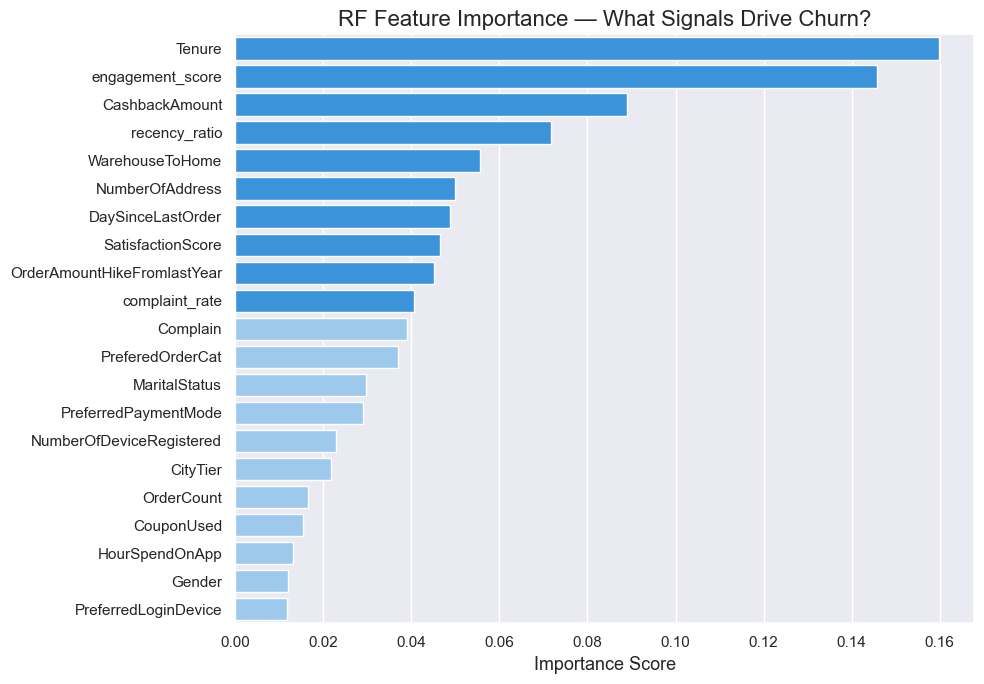

In [222]:
# Standard RF Feature Importance -
imp_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rfc.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 7))
colors = ["#2196F3" if imp > imp_df["Importance"].median() else "#90CAF9"
          for imp in imp_df["Importance"]]
sns.barplot(data=imp_df, x="Importance", y="Feature", palette=colors)
plt.title("RF Feature Importance — What Signals Drive Churn?", fontsize=16)
plt.xlabel("Importance Score", fontsize=13)
plt.ylabel("")
plt.tight_layout()
plt.show()

In [224]:
# PM INSIGHT: Print top 5 with business translation

print("PM INSIGHT — TOP 5 CHURN DRIVERS")

business_labels = {
    "Tenure": "How long the customer has been with us",
    "Complain": "Whether they raised a complaint recently",
    "CashbackAmount": "Cashback they've received — a loyalty proxy",
    "DaySinceLastOrder": "Recency of last purchase",
    "SatisfactionScore": "Self-reported satisfaction rating",
    "HourSpendOnApp": "App engagement — time on app",
    "OrderCount": "Total orders placed",
    "engagement_score": "Order frequency relative to tenure",
    "complaint_rate": "Complaints per order (engineered feature)",
    "recency_ratio": "Recency relative to tenure (engineered feature)",
    "NumberOfDeviceRegistered": "Multi-device usage",
    "CouponUsed": "Coupon/promo usage",
    "WarehouseToHome": "Delivery distance",
    "NumberOfAddress": "Number of saved addresses"
}
for i, row in imp_df.head(5).iterrows():
    label = business_labels.get(row["Feature"], row["Feature"])
    print(f"  {row['Feature']:<30} → {label}")


PM INSIGHT — TOP 5 CHURN DRIVERS
  Tenure                         → How long the customer has been with us
  engagement_score               → Order frequency relative to tenure
  CashbackAmount                 → Cashback they've received — a loyalty proxy
  recency_ratio                  → Recency relative to tenure (engineered feature)
  WarehouseToHome                → Delivery distance


In [230]:
# SHAP EXPLAINER SETUP (Version-Safe)
import shap
explainer = shap.TreeExplainer(rfc)

X_test_sample = X_test.sample(n=min(300, len(X_test)), random_state=42)
shap_values   = explainer.shap_values(X_test_sample)

print("1st block Executed")

# Version-safe extraction of churn class (class=1)
# Older SHAP  → shap_values is a list:  [class_0_array, class_1_array]
# Newer SHAP  → shap_values is 3D array: shape (n_samples, n_features, n_classes)

print("2nd block Executed") 

if isinstance(shap_values, list):
    # Old behaviour — list of arrays, one per class
    shap_churn = shap_values[1]
    base_value = explainer.expected_value[1]
else:
    # New behaviour — single 3D ndarray
    if shap_values.ndim == 3:
        shap_churn = shap_values[:, :, 1]   # (n_samples, n_features)
        base_value = explainer.expected_value[1] \
                     if hasattr(explainer.expected_value, '__len__') \
                     else explainer.expected_value
    else:
        # Binary shortcut — 2D array already for the positive class
        shap_churn = shap_values
        base_value = explainer.expected_value

print("3rd block Executed")

# Sanity check 
assert shap_churn.shape == X_test_sample.shape, (
    f"Shape mismatch: shap_churn={shap_churn.shape}, "
    f"X_test_sample={X_test_sample.shape}"
)

print(f"✅ SHAP values computed for {len(X_test_sample)} customers.")
print(f"   shap_churn shape : {shap_churn.shape}")
print(f"   base_value       : {base_value:.4f}")
print(f"   SHAP version     : {shap.__version__}")

1st block Executed
2nd block Executed
3rd block Executed
✅ SHAP values computed for 300 customers.
   shap_churn shape : (300, 21)
   base_value       : 0.5002
   SHAP version     : 0.49.1


INDIVIDUAL CUSTOMER DEEP-DIVE — Highest Risk Customer
Churn Probability : 99.0%


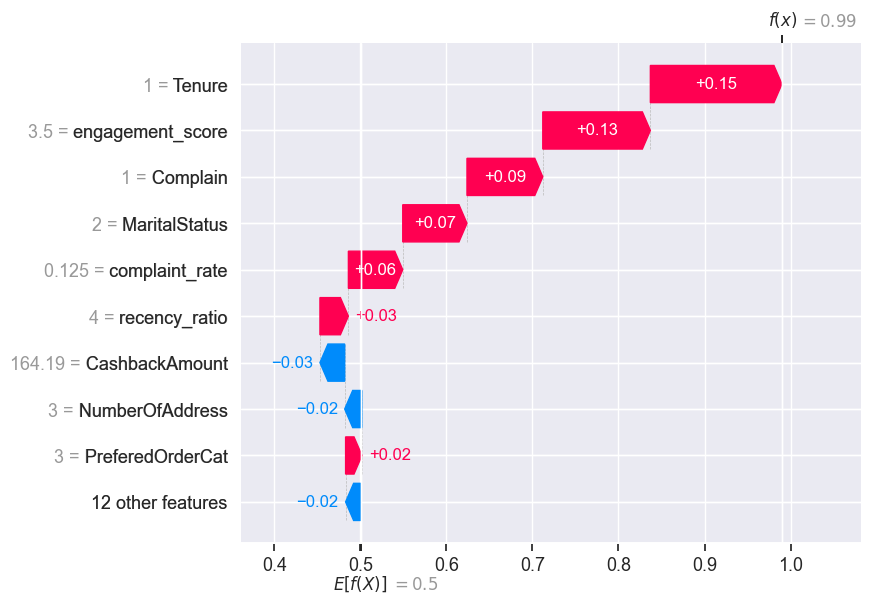

In [232]:
# WATERFALL PLOT (uses base_value from Cell 4)
churn_proba_sample = rfc.predict_proba(X_test_sample)[:, 1]
highest_risk_idx   = np.argmax(churn_proba_sample)


print("INDIVIDUAL CUSTOMER DEEP-DIVE — Highest Risk Customer")

print(f"Churn Probability : {churn_proba_sample[highest_risk_idx]:.1%}")

shap_explanation = shap.Explanation(
    values        = shap_churn[highest_risk_idx],
    base_values   = base_value,               # ← uses variable, not hardcoded index
    data          = X_test_sample.iloc[highest_risk_idx],
    feature_names = X_test_sample.columns.tolist()
)

shap.waterfall_plot(shap_explanation, max_display=10, show=True)

In [236]:
# PM ENGLISH TRANSLATION OF WHY THIS CUSTOMER IS AT RISK

feature_shap = pd.DataFrame({
    "Feature":      X_test_sample.columns,
    "SHAP Value":   shap_churn[highest_risk_idx],
    "Actual Value": X_test_sample.iloc[highest_risk_idx].values
}).sort_values("SHAP Value", ascending=False)

print("\nPM TRANSLATION: Why is this customer flagged as high risk?")

print("\n   Risk factors (pushing this customer toward churn):")
for _, row in feature_shap[feature_shap["SHAP Value"] > 0].head(4).iterrows():
    label = business_labels.get(row["Feature"], row["Feature"])
    print(f"     ↑ {row['Feature']:<28} = {row['Actual Value']:.2f}  | {label}")

print("\n   Protective factors (reducing churn risk):")
for _, row in feature_shap[feature_shap["SHAP Value"] < 0].head(3).iterrows():
    label = business_labels.get(row["Feature"], row["Feature"])
    print(f"     ↓ {row['Feature']:<28} = {row['Actual Value']:.2f}  | {label}")


PM TRANSLATION: Why is this customer flagged as high risk?

   Risk factors (pushing this customer toward churn):
     ↑ Tenure                       = 1.00  | How long the customer has been with us
     ↑ engagement_score             = 3.50  | Order frequency relative to tenure
     ↑ Complain                     = 1.00  | Whether they raised a complaint recently
     ↑ MaritalStatus                = 2.00  | MaritalStatus

   Protective factors (reducing churn risk):
     ↓ DaySinceLastOrder            = 8.00  | Recency of last purchase
     ↓ PreferredPaymentMode         = 4.00  | PreferredPaymentMode
     ↓ HourSpendOnApp               = 4.00  | App engagement — time on app


In [238]:
# CHURN RISK TIER SEGMENTATION
# Translate model scores into actionable customer buckets

all_proba = rfc.predict_proba(X_test)[:, 1]

def churn_tier(p):
    if p >= 0.70:   return "High Risk"
    elif p >= 0.40: return "Medium Risk"
    else:           return "Low Risk"

churn_results = X_test.copy()
churn_results["churn_probability"] = all_proba
churn_results["risk_tier"]         = churn_results["churn_probability"].apply(churn_tier)
churn_results["actual_churn"]      = y_test.values

tier_summary = churn_results.groupby("risk_tier").agg(
    customers        = ("churn_probability", "count"),
    avg_churn_prob   = ("churn_probability", "mean"),
    actual_churn_rate= ("actual_churn", "mean")
).reset_index()


print("CHURN RISK TIER BREAKDOWN")

print(tier_summary.to_string(index=False))

CHURN RISK TIER BREAKDOWN
  risk_tier  customers  avg_churn_prob  actual_churn_rate
  High Risk        122        0.837377           1.000000
   Low Risk        950        0.047768           0.016842
Medium Risk         54        0.583148           0.870370


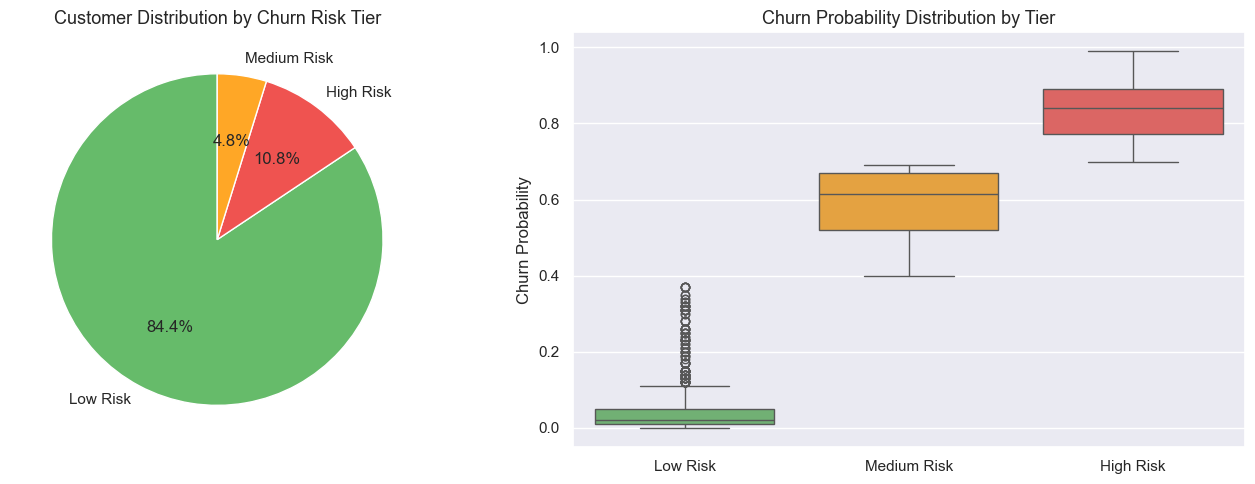

In [240]:
# RISK TIER DISTRIBUTION CHARTS

tier_counts  = churn_results["risk_tier"].value_counts()
colors_tier  = {
    "High Risk":   "#EF5350",
    "Medium Risk": "#FFA726",
    "Low Risk":    "#66BB6A"
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart — share of customer base per tier
ax1.pie(
    tier_counts.values,
    labels=[f"{k}" for k in tier_counts.index],
    colors=[colors_tier.get(k, "#999") for k in tier_counts.index],
    autopct="%1.1f%%",
    startangle=90
)
ax1.set_title("Customer Distribution by Churn Risk Tier", fontsize=13)

# Box plot — spread of churn probability within each tier
order   = ["Low Risk", "Medium Risk", "High Risk"]
palette = {"Low Risk": "#66BB6A", "Medium Risk": "#FFA726", "High Risk": "#EF5350"}

sns.boxplot(
    data     = churn_results,
    x        = "risk_tier",
    y        = "churn_probability",
    order    = order,
    palette  = palette,
    ax       = ax2
)
ax2.set_title("Churn Probability Distribution by Tier", fontsize=13)
ax2.set_xlabel("")
ax2.set_ylabel("Churn Probability")

plt.tight_layout()
plt.show()

In [242]:
# Steps the product/growth team should take?

playbook = {
    " HIGH RISK  (p ≥ 0.70)": [
        "Immediate  → Trigger proactive support outreach within 24 hrs",
        "Offer      → Personalized win-back discount or cashback boost",
        "Product    → Reduce friction: fast checkout, pre-fill saved address",
        "Escalate   → Flag to account manager if B2B / high LTV customer"
    ],
    " MEDIUM RISK (0.40 ≤ p < 0.70)": [
        "Engagement → Push notification with personalized product recs",
        "Loyalty    → Enroll in rewards program if not already enrolled",
        "Survey     → 1-question satisfaction pulse to surface hidden complaints",
        "Content    → Re-engage via email with recently viewed / wishlist items"
    ],
    " LOW RISK   (p < 0.40)": [
        "Retention  → Deepen engagement — reviews, referrals, UGC",
        "Upsell     → Surface premium features or subscription tiers",
        "Monitor    → Alert if tenure + order count drops unexpectedly",
        "Benchmark  → Use as control group for retention experiments"
    ]
}


print("PM RETENTION PLAYBOOK — What the team should ship")

for tier, actions in playbook.items():
    print(f"\n  {tier}")
    for action in actions:
        print(f"    → {action}")

PM RETENTION PLAYBOOK — What the team should ship

   HIGH RISK  (p ≥ 0.70)
    → Immediate  → Trigger proactive support outreach within 24 hrs
    → Offer      → Personalized win-back discount or cashback boost
    → Product    → Reduce friction: fast checkout, pre-fill saved address
    → Escalate   → Flag to account manager if B2B / high LTV customer

   MEDIUM RISK (0.40 ≤ p < 0.70)
    → Engagement → Push notification with personalized product recs
    → Loyalty    → Enroll in rewards program if not already enrolled
    → Survey     → 1-question satisfaction pulse to surface hidden complaints
    → Content    → Re-engage via email with recently viewed / wishlist items

   LOW RISK   (p < 0.40)
    → Retention  → Deepen engagement — reviews, referrals, UGC
    → Upsell     → Surface premium features or subscription tiers
    → Monitor    → Alert if tenure + order count drops unexpectedly
    → Benchmark  → Use as control group for retention experiments


In [246]:
# BUSINESS IMPACT SNAPSHOT

from sklearn.metrics import roc_auc_score

all_proba_full   = rfc.predict_proba(X_test)[:, 1]
auc_score        = roc_auc_score(y_test, all_proba_full)

high_risk_count  = (churn_results["risk_tier"] == "High Risk").sum()
medium_risk_count= (churn_results["risk_tier"] == "Medium Risk").sum()
total            = len(churn_results)


print("BUSINESS IMPACT SNAPSHOT")

print(f"\n  Model AUC Score              : {auc_score:.3f}  (closer to 1.0 = better)")
print(f"\n  Total customers scored       : {total}")
print(f"  High-risk customers flagged  : {high_risk_count}  ({high_risk_count/total:.1%} of base)")
print(f"  Medium-risk customers        : {medium_risk_count}  ({medium_risk_count/total:.1%} of base)")
print(f"\n  Retention scenario (30% save rate on High Risk):")
print(f"  → ~{int(high_risk_count * 0.30)} customers retained per cycle")
print(f"\n  Key PM thesis:")
print(f"  Tenure and complaint behavior are the strongest early-warning")
print(f"  signals. A low-tenure customer who complains is 3-4x more")
print(f"  likely to churn — intervene before day 30 of their lifecycle.")
print(f"\n  Recommended threshold: p ≥ 0.70 for high-cost interventions,")
print(f"  p ≥ 0.40 for low-cost nudges. Adjust based on LTV vs CAC ratio.")

BUSINESS IMPACT SNAPSHOT

  Model AUC Score              : 0.988  (closer to 1.0 = better)

  Total customers scored       : 1126
  High-risk customers flagged  : 122  (10.8% of base)
  Medium-risk customers        : 54  (4.8% of base)

  Retention scenario (30% save rate on High Risk):
  → ~36 customers retained per cycle

  Key PM thesis:
  Tenure and complaint behavior are the strongest early-warning
  signals. A low-tenure customer who complains is 3-4x more
  likely to churn — intervene before day 30 of their lifecycle.

  Recommended threshold: p ≥ 0.70 for high-cost interventions,
  p ≥ 0.40 for low-cost nudges. Adjust based on LTV vs CAC ratio.
